# Full continental run — SIMPLACE and TorchCrop, together

**What this notebook does.** It reads each model's own `winter_wheat_2000_2024`
production run exactly as
[`submit/submit_cropmodelling.sh`](../submit/submit_cropmodelling.sh) writes
it — `cm4eu simplace collect`'s `simplace_europe.parquet` and the shard
combine's `torchcrop_europe.parquet` — compares both against two
external references on the finest units either publishes — the **CyBench**
yield per reported administrative unit and year (§4), and the **CLMS HRL
Croplands** observed emergence and harvest per unit *and season* (§5) — and
then compares the two models directly against each other over the whole
domain (§6).

**Every choropleth in §4 and §5 is drawn on the CyBench reporting units** —
NUTS-3 for fifteen of the evaluable countries, NUTS-2 for the other eight.
That is the finest resolution the yield reference supports, and it is the
zoning `data4simplace`'s phenology stage reduces the 10 m CLMS rasters over,
so neither comparison has to be averaged up to the country first. The
national maps that remain are explicitly labelled roll-ups of the unit pairs
(§4.8, §5.6), kept as the coarse contrast that shows how much structure the
aggregation removes.

**§5 no longer uses CyBench's crop calendar.** That reference is static — one
`sos`/`eos` per unit, no year dimension — so it can only penalise a model for
varying between seasons, never reward it for varying correctly. CLMS carries
a date per season, which is what §5.4's split into spatial and interannual
skill needs. The price is 2017-2024 instead of the full record, and a harvest
level that sits ~29 days earlier than CyBench's `eos`; §5.2 measures that
offset before any model bias is read.

**How this differs from the other two-model notebooks.**
`germany_smoke_evaluation.ipynb` matches 30 cells and hands SIMPLACE's own
simulated sowing dates to torchcrop by construction; `stresstest_evaluation.ipynb`
forces every non-model input equal (crop parameters, spin-up, irrigation,
CO₂). Neither one is what ships. This notebook reads whatever each pipeline
actually produced for the full run — a different sowing convention on each
side unless the run was submitted through the chain (SIMPLACE's simulated
dates handed to torchcrop), a cell set that need not match exactly — because
the question here is what the delivered output says, not an idealised
comparison.

**The one difference §2 does not leave alone is the year range.**
`season.start_year`/`end_year` (which torchcrop honours) and
`simplace.start_date`/`end_date` (which SIMPLACE honours) are independent
`config.yaml` knobs, and this run set them inconsistently: SIMPLACE simulated
1979-2024 while torchcrop simulated only its configured 2000-2024. Comparing
either model's full record against CyBench, or the two against each other,
would silently mix in 20 SIMPLACE-only seasons no torchcrop number ever saw.
§2 trims every model down to the seasons they share before anything else
runs; the raw parquet files still carry the extra seasons.

**Either run can be missing, and the notebook says so rather than failing.**
`fullrun.load_runs` skips a model with no Parquet yet and logs a warning; §2
reports which models loaded. §4-5 run per model over whichever are present;
§6, which needs both, prints a note and stops there if only one is.

Four conventions carried over from the single-model notebooks:

1. **Error is `simulated − observed`** against CyBench (§4-5); `torchcrop −
   simplace` in the direct comparison (§6), where neither side is a
   reference — see `evaluation.fullrun.pair_models`.
2. **No moisture conversion.** Both models report grain dry matter; CyBench
   reports market moisture (~13.5 %), so part of any negative bias against it
   is that unit difference rather than model error.
3. **The simulated mean is unweighted** over the cropland cells of whichever
   unit it is taken over — the export carries no per-cell wheat area to weight
   by.
4. **Day-of-year statistics are circular** (`doy.circular_mean_doy`,
   `doy.doy_difference`), for the reason `phenology_evaluation.ipynb`'s header
   gives: Spain's regional `sos` runs from DOY 0.7 to 363. §5 is where that
   matters most — see §5.1 on why the national circular mean was the wrong
   number to compare against in the first place.

All reusable code is in
[`../src/cropmodelling4eu/evaluation/`](../src/cropmodelling4eu/evaluation/);
this notebook is the workflow only.


## 0. Setup

In [1]:
import logging
import sys
from pathlib import Path

# cropmodelling4eu is installed (pip install -e .), so the evaluation
# library is imported like any other package rather than off sys.path.

import colormaps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cropmodelling4eu.evaluation as cmeval

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = cmeval.style.use_style("light")
cmeval.config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"SIMPLACE run  : {cmeval.config.SIMPLACE_PARQUET}",
      "(found)" if cmeval.config.SIMPLACE_PARQUET.is_file() else "(not finished yet)")
print(f"TorchCrop run : {cmeval.config.SIM_PARQUET}",
      "(found)" if cmeval.config.SIM_PARQUET.is_file() else "(not finished yet)")
print(f"CyBench root  : {cmeval.config.CYBENCH_ROOT}")
print(f"CLMS phenology: {cmeval.config.CLMS_PHENOLOGY_DIR}",
      "(found)" if (cmeval.config.CLMS_PHENOLOGY_DIR / cmeval.config.CLMS_PHENOLOGY_FILES["adm"]).is_file() else "(missing)")
print(f"Outputs       : {cmeval.config.OUTPUT_DIR}")
print(f"\nCLMS adm file : {cmeval.config.CLMS_PHENOLOGY_DIR / cmeval.config.CLMS_PHENOLOGY_FILES['adm']}")

SIMPLACE run  : /data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/winter_wheat_2000_2024/simplace/simplace_europe.parquet (found)
TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/winter_wheat_2000_2024/torchcrop/torchcrop_europe.parquet (found)
CyBench root  : /data01/FDS/muduchuru/Data/Agri/cybench
CLMS phenology: /data01/FDS/muduchuru/Data/SIMPLACE/EU/validation/phenology (found)
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs

CLMS adm file : /data01/FDS/muduchuru/Data/SIMPLACE/EU/validation/phenology/phenology_adm.parquet


## 1. Scope — which countries are evaluable

A country needs a CyBench yield file *and* CyBench polygons: the file supplies
the reference, the polygons decide which 10 km cells belong to it.

In [2]:
COUNTRIES = cmeval.config.available_countries()

scope = pd.DataFrame({
    "code": list(cmeval.config.TARGET_COUNTRIES),
    "name": [cmeval.config.COUNTRY_NAMES.get(c, c) for c in cmeval.config.TARGET_COUNTRIES],
    "eu27": [c in cmeval.config.EU27 for c in cmeval.config.TARGET_COUNTRIES],
    "schengen_non_eu": [c in cmeval.config.SCHENGEN_NON_EU for c in cmeval.config.TARGET_COUNTRIES],
    "in_cybench": [c in COUNTRIES for c in cmeval.config.TARGET_COUNTRIES],
}).set_index("code")

print(f"{len(COUNTRIES)} of {len(cmeval.config.TARGET_COUNTRIES)} target countries are evaluable")
print("missing:", ", ".join(scope.index[~scope["in_cybench"]]))
scope

23 of 31 target countries are evaluable
missing: CH, CY, IS, LI, LU, MT, NO, SI


,name,eu27,schengen_non_eu,in_cybench
code,,,,
AT,Austria,True,False,True
BE,Belgium,True,False,True
BG,Bulgaria,True,False,True
CH,Switzerland,False,True,False
CY,Cyprus,True,False,False
CZ,Czechia,True,False,True
DE,Germany,True,False,True
DK,Denmark,True,False,True
EE,Estonia,True,False,True


## 2. Load both runs

One row per (cell, season) on each side. `fullrun.load_runs` reads each with
its own model's rules — SIMPLACE's collector already writes the dates it
simulated, torchcrop's `days_to_maturity` is turned into dates by
`torchcrop.add_phenology_columns` — and tags every row with `model`. A model
with no Parquet yet is skipped with a warning, not raised on.

In [3]:
# Calibrated per-region run: torchcrop on the reference SIMPLACE sowing (what the
# calibration was fitted on), SIMPLACE from the 28 per-region builds, with the
# 84 inconsistent duplicate season rows removed (simplace_europe_raw.parquet keeps them).
ROOT = Path("/data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/winter_wheat_2000_2024_euval")
runs = cmeval.fullrun.load_runs(
    simplace_path=ROOT / "simplace_europe.parquet",
    torchcrop_path=ROOT / "torchcrop_regions_sowing" / "torchcrop_europe.parquet",
)
print(f"\nmodels loaded: {', '.join(runs)}")
for model, frame in runs.items():
    print(f"{model:10s}: {len(frame):>9,} cell-seasons, "
          f"{frame['SimplaceID'].nunique():>6,} cells, "
          f"{frame['year'].min()}-{frame['year'].max()}")

pd.concat(
    {model: frame[["yield_t_ha", "days_to_maturity"]].describe()
     for model, frame in runs.items()},
    axis=1,
)

INFO cropmodelling4eu.evaluation.torchcrop: read torchcrop_europe.parquet: 1711524 rows, 22 columns
INFO cropmodelling4eu.evaluation.torchcrop: using the run's own per-cell sowing date (140 distinct values, 215-366)
WARNING cropmodelling4eu.evaluation.torchcrop: 207 of 1711524 rows (0.01%) never reached maturity; their dates are NaN
WARNING cropmodelling4eu.evaluation.fullrun: simplace: 24997 of 3088694 rows (0.81%) carry a season shorter than 150 days -- the (0, 365] wrap in collect.to_run_schema, not a 5-day crop. Their durations are dropped; their dates are kept
INFO cropmodelling4eu.evaluation.fullrun: torchcrop: 1711524 cell-seasons, 68685 cells, 2000-2024
INFO cropmodelling4eu.evaluation.fullrun: simplace: 3088694 cell-seasons, 68685 cells, 1979-2024



models loaded: torchcrop, simplace
torchcrop : 1,711,524 cell-seasons, 68,685 cells, 2000-2024
simplace  : 3,088,694 cell-seasons, 68,685 cells, 1979-2024


torchcrop                       simplace                 
         yield_t_ha days_to_maturity    yield_t_ha days_to_maturity
count  1.711524e+06     1.711317e+06  3.088694e+06     3.063697e+06
mean   4.533818e+00     3.076014e+02  5.477951e+00     3.061315e+02
std    2.227241e+00     3.695202e+01  2.206951e+00     3.882586e+01
min    0.000000e+00     1.680000e+02  1.503232e-02     1.500000e+02
25%    2.954473e+00     2.920000e+02  3.941027e+00     2.910000e+02
50%    4.501573e+00     3.140000e+02  5.593789e+00     3.140000e+02
75%    5.893783e+00     3.350000e+02  6.940873e+00     3.350000e+02
max    1.123015e+01     4.470000e+02  1.309116e+01     3.650000e+02

In [4]:
# Constrain every model to the seasons they *all* cover. `season.start_year`/
# `end_year` (torchcrop) and `simplace.start_date`/`end_date` are independent
# config knobs -- this run set them inconsistently, so SIMPLACE simulated
# 1979-2024 while torchcrop simulated only its configured 2000-2024. Trimming
# here, once, means every section below (CyBench comparisons in §4-5 as well
# as the direct comparison in §6) reads the same window on both sides, rather
# than SIMPLACE's extra 1979-1999 seasons only dropping out of §6's inner join.
common_years = set.intersection(*(set(frame["year"].unique()) for frame in runs.values()))
lo, hi = min(common_years), max(common_years)
print(f"Constraining every model to the {len(common_years)} seasons they share ({lo}-{hi}).")

for model in list(runs):
    before = len(runs[model])
    runs[model] = runs[model][runs[model]["year"].isin(common_years)].copy()
    dropped = before - len(runs[model])
    if dropped:
        print(f"  {model:10s}: dropped {dropped:>9,} cell-seasons outside the shared window "
              f"({len(runs[model]):,} remain)")

Constraining every model to the 25 seasons they share (2000-2024).
  simplace  : dropped 1,372,029 cell-seasons outside the shared window (1,716,665 remain)


## 3. Assign each 10 km cell to a country

Built from the **union** of both models' cells: both pipelines read the same
10 km export, so they share one grid, and one country join covers whichever
model (or both) is present. Cells outside the CyBench footprint — the UK,
Norway, Switzerland, the western Balkans, North Africa — are dropped from
every model.

In [5]:
all_cells = cmeval.torchcrop.simulation_cells(
    pd.concat([frame[["SimplaceID", "lon", "lat"]] for frame in runs.values()],
              ignore_index=True)
)
all_cells = cmeval.regions.assign_cells_to_countries(
    all_cells, COUNTRIES, cache=cmeval.regions.default_cache_path(len(COUNTRIES))
)
print(f"{all_cells['country'].notna().sum():,} of {len(all_cells):,} cells "
      f"inside the CyBench footprint ({all_cells['snapped'].sum():,} matched "
      f"by the {cmeval.config.SNAP_KM} km snap)")

scoped = {}
for model, frame in runs.items():
    tagged = frame.merge(all_cells[["SimplaceID", "country", "snapped"]],
                          on="SimplaceID", how="left")
    scoped[model] = tagged[tagged["country"].notna()].copy()
    print(f"{model:10s}: {len(scoped[model]):>9,} of {len(frame):>9,} "
          f"cell-seasons kept")

cells_per_country = (
    all_cells.dropna(subset=["country"]).groupby("country").size()
    .rename("cells").to_frame()
)
cells_per_country.T

INFO cropmodelling4eu.evaluation.torchcrop: 68685 unique cells
INFO cropmodelling4eu.evaluation.regions: cell-to-country map read from /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/cache/cell_country_n23_snap5km.parquet


30,406 of 68,685 cells inside the CyBench footprint (779 matched by the 5.0 km snap)
torchcrop :   759,975 of 1,711,524 cell-seasons kept
simplace  :   760,145 of 1,716,665 cell-seasons kept


country,AT,BE,BG,CZ,DE,DK,EE,EL,ES,FI,...,IE,IT,LT,LV,NL,PL,PT,RO,SE,SK
cells,398,378,978,826,4297,729,471,602,3258,120,...,279,1710,861,757,424,3880,376,2025,778,465


## 4. Yield at the reported administrative unit — both models against CyBench

CyBench publishes no national wheat yield. It publishes a **sub-national** one,
on the units each statistical office reports: **NUTS-3** for fifteen of the
evaluable countries (Germany's 397 Kreise, France's 95 départements, Italy's 97
province) and **NUTS-2** for the other eight (Poland's 17 voivodeships,
Austria's 9 Länder, the Netherlands' 12 provincies). This section pairs on
those units, instead of averaging both sides up to the country first.

**Why the reported unit and not the country.** The unit is the finest
resolution the *observation* actually supports, so pairing there is the
strongest test the reference can carry — and a national mean hides exactly the
error a gridded model is most likely to make: too high in one half of a country
and too low in the other cancels to a perfect national score. It also multiplies
the paired points by roughly thirty. The country-level view is not lost, it is
**derived**: §4.6 rolls the unit pairs up per country, so the number in the
table and the map beneath it describe one and the same comparison.

**What it costs, stated up front rather than discovered later:**

* **Two resolutions in one pool.** A NUTS-3 pair and a NUTS-2 pair are not
  equally hard, so §4.5 reports skill split by level as well as pooled — one
  blended number would flatter whichever level happens to dominate the count.
* **Thin units.** `regions.assign_cells_to_regions` gives each 10 km cell to
  exactly one unit, by its centre. A large département gets forty cells; a
  small Kreis gets one, and its "simulated mean" is then a single cell. Every
  pair carries `n_cells` and §4.5 re-scores the well-covered subset, because
  those two are not the same measurement.
* **Still unweighted.** The simulated mean over a unit's cropland cells has no
  per-cell wheat area to weight by — the export carries none — exactly as at
  national level. The observed side needs no weighting at all here: this *is*
  the reported number, not an average of reported numbers.

### 4.1 Assign each cell to the unit its yield is reported on

In [6]:
admin = cmeval.regions.load_admin_polygons(COUNTRIES)
admin["level"] = cmeval.regions.nuts_level(admin["adm_id"])

all_cells = cmeval.regions.assign_cells_to_regions(
    all_cells, COUNTRIES,
    cache=cmeval.regions.default_cache_path(len(COUNTRIES), prefix="cell_region"),
)
print(f"{all_cells['adm_id'].notna().sum():,} of {len(all_cells):,} cells carry an "
      f"administrative unit ({all_cells['adm_snapped'].sum():,} matched by the "
      f"{cmeval.config.SNAP_KM} km snap)")

# The country join of §3 and this one run over the same polygons, dissolved and
# not, so containment cannot disagree between them -- only the snap pass can,
# by reaching a different neighbour. Counted rather than assumed away.
labelled = all_cells.dropna(subset=["country", "adm_id"])
crossed = int((labelled["country"] != labelled["adm_country"]).sum())
print(f"{crossed} cells whose unit lies in a different country than their §3 label")

# A country that published two levels would make the level column meaningless.
spread = admin.groupby("country")["level"].agg(["min", "max"])
mixed = spread.index[spread["min"] != spread["max"]].tolist()
print("countries mixing NUTS levels:", mixed or "none")

scoped_adm = {}
for model, frame in scoped.items():
    tagged = frame.merge(all_cells[["SimplaceID", "adm_id", "adm_snapped"]],
                         on="SimplaceID", how="left")
    scoped_adm[model] = tagged[tagged["adm_id"].notna()].copy()
    print(f"{model:10s}: {len(scoped_adm[model]):>9,} of {len(frame):>9,} "
          f"cell-seasons inside a reported unit")

INFO cropmodelling4eu.evaluation.regions: 946 admin polygons across 23 countries
INFO cropmodelling4eu.evaluation.regions: cell-to-region map read from /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/cache/cell_region_n23_snap5km.parquet


30,406 of 68,685 cells carry an administrative unit (779 matched by the 5.0 km snap)
0 cells whose unit lies in a different country than their §3 label
countries mixing NUTS levels: none
torchcrop :   759,975 of   759,975 cell-seasons inside a reported unit
simplace  :   760,145 of   760,145 cell-seasons inside a reported unit


### 4.2 How well is each reported unit covered by the 10 km grid?

In [7]:
covered = all_cells.dropna(subset=["adm_id"])
per_unit = covered.groupby(["adm_country", "adm_id"]).size()

reported = (
    admin.groupby("country")
    .agg(level=("level", "max"), units_published=("adm_id", "nunique"))
    .join(covered.groupby("adm_country")
          .agg(units_covered=("adm_id", "nunique"), cells=("SimplaceID", "size")))
    .join(per_unit.groupby("adm_country").median().rename("median_cells_per_unit"))
    .join(per_unit.groupby("adm_country").apply(lambda s: (s == 1).sum())
          .rename("units_on_one_cell"))
    .assign(level=lambda d: "NUTS-" + d["level"].astype("Int64").astype(str))
    .sort_values(["level", "units_published"], ascending=[True, False])
)
print(reported.groupby("level")[["units_published", "units_covered", "cells"]].sum()
      .to_string())
reported

        units_published  units_covered  cells
level                                        
NUTS-2               67             64   7098
NUTS-3              879            785  23308


,level,units_published,units_covered,cells,median_cells_per_unit,units_on_one_cell
country,,,,,,
PL,NUTS-2,17,17,3880,238.0,0
NL,NUTS-2,12,12,424,33.5,0
BE,NUTS-2,11,11,378,37.0,1
AT,NUTS-2,9,8,398,36.0,2
PT,NUTS-2,7,5,376,27.0,0
BG,NUTS-2,6,6,978,159.5,0
IE,NUTS-2,3,3,279,128.0,0
HR,NUTS-2,2,2,385,192.5,0
DE,NUTS-3,401,378,4297,9.0,40


### 4.3 Aggregate each model to the unit, and pair against CyBench

In [8]:
# Every unit a cell reaches is paired; §4.5 re-scores the >= 3 cell subset
# separately rather than dropping the thin units silently here.
MIN_CELLS_PER_UNIT = 1

obs = cmeval.cybench.load_yield(COUNTRIES)
obs_region = (
    obs.rename(columns={"harvest_year": "year", "yield": "obs_yield"})
    .groupby(["country", "adm_id", "year"], as_index=False)
    .agg(obs_yield=("obs_yield", "mean"), n_reports=("obs_yield", "size"))
)
duplicated = int((obs_region["n_reports"] > 1).sum())
if duplicated:
    print(f"{duplicated} (unit, year) keys carry more than one reported yield; "
          "averaged")

yield_paired = []
for model, frame in scoped_adm.items():
    sim_region = cmeval.aggregate.aggregate_simulated(
        frame, {"yield_t_ha": False}, by=["country", "adm_id", "year"]
    )
    sim_region = sim_region[sim_region["n_cells"] >= MIN_CELLS_PER_UNIT]
    paired = cmeval.aggregate.pair_observations(
        sim_region, obs_region, ["country", "adm_id", "year"]
    )
    paired["model"] = model
    paired["residual"] = paired["yield_t_ha"] - paired["obs_yield"]
    yield_paired.append(paired)
yield_paired = pd.concat(yield_paired, ignore_index=True)
yield_paired["nuts_level"] = cmeval.regions.nuts_level(yield_paired["adm_id"])

print(f"\n{len(yield_paired):,} paired (model, unit, year) rows across "
      f"{yield_paired['adm_id'].nunique():,} units and "
      f"{yield_paired['country'].nunique()} countries")
yield_paired.head()

INFO cropmodelling4eu.evaluation.cybench: dropped 28 rows with a missing or non-positive yield
INFO cropmodelling4eu.evaluation.cybench: observed yields: 24735 rows, 23 countries, 1979-2021, 54% area-weighted
INFO cropmodelling4eu.evaluation.aggregate: simulated: 21217 country-groups, 1-388 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 14923 rows; 6294 simulated-only and 9812 observed-only dropped
INFO cropmodelling4eu.evaluation.aggregate: simulated: 21225 country-groups, 1-388 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 14929 rows; 6296 simulated-only and 9806 observed-only dropped



29,852 paired (model, unit, year) rows across 805 units and 23 countries


,country,adm_id,year,yield_t_ha,sim_method,n_cells,obs_yield,n_reports,model,residual,nuts_level
0,AT,AT11,2000,3.238790,unweighted,45,3.542,1,torchcrop,-0.303210,2
1,AT,AT11,2001,3.986560,unweighted,45,4.340,1,torchcrop,-0.353440,2
2,AT,AT11,2002,4.637068,unweighted,45,4.160,1,torchcrop,0.477068,2
3,AT,AT11,2003,2.855595,unweighted,45,3.640,1,torchcrop,-0.784405,2
4,AT,AT11,2004,5.489572,unweighted,45,5.250,1,torchcrop,0.239572,2


### 4.4 Pooled skill, both models

In [9]:
yield_pooled = {
    model: cmeval.metrics.yield_metrics(block["obs_yield"], block["yield_t_ha"])
    for model, block in yield_paired.groupby("model")
}
yield_pooled_table = pd.DataFrame(yield_pooled).T[list(cmeval.metrics.YIELD_METRIC_ORDER)]
yield_pooled_table.round(3)

,n,obs_mean,sim_mean,bias,mae,rmse,mape,r2,pearson_r
simplace,14929.0,5.948,7.118,1.170,1.500,1.858,37.537,0.223,0.741
torchcrop,14923.0,5.948,6.403,0.454,0.867,1.124,20.021,0.716,0.874


### 4.5 Does the level, or the cell coverage, change the answer?

Two cuts of the same pairs. **By NUTS level**, because the pooled row above
mixes them and the count is dominated by NUTS-3. **By cells per unit**,
because a unit whose simulated yield rests on one 10 km cell is being asked a
question the grid cannot answer — if skill improves sharply on the
well-covered subset, the pooled number is measuring resolution rather than the
model.

`sparse` (1-2 cells) against `resolved` (>= 3) is the same threshold
`config.MIN_CELLS_PER_GRIDCELL` uses for the 0.5° gridded comparisons, and for
the same reason.

In [10]:
RESOLVED_CELLS = cmeval.config.MIN_CELLS_PER_GRIDCELL

subset_rows = []
for model, block in yield_paired.groupby("model"):
    cuts = {
        "all pairs": block,
        **{f"NUTS-{int(lvl)}": part
           for lvl, part in block.groupby("nuts_level", dropna=True)},
        f"sparse (< {RESOLVED_CELLS} cells)": block[block["n_cells"] < RESOLVED_CELLS],
        f"resolved (>= {RESOLVED_CELLS} cells)": block[block["n_cells"] >= RESOLVED_CELLS],
    }
    for label, part in cuts.items():
        if part.empty:
            continue
        subset_rows.append(
            cmeval.metrics.yield_metrics(part["obs_yield"], part["yield_t_ha"])
            | {"model": model, "subset": label, "units": part["adm_id"].nunique()}
        )

yield_by_subset = (
    pd.DataFrame(subset_rows)
    .set_index(["subset", "model"])[["units", *cmeval.metrics.YIELD_METRIC_ORDER]]
)
yield_by_subset.to_csv(
    cmeval.config.TABLE_DIR / "full_run_yield_metrics_by_subset.csv", float_format="%.3f"
)
yield_by_subset.round(2)

,,units,n,obs_mean,sim_mean,bias,mae,rmse,mape,r2,pearson_r
subset,model,,,,,,,,,,
all pairs,simplace,805,14929,5.95,7.12,1.17,1.50,1.86,37.54,0.22,0.74
NUTS-2,simplace,64,1083,5.84,7.41,1.57,1.80,2.20,55.67,0.22,0.79
NUTS-3,simplace,741,13846,5.96,7.09,1.14,1.48,1.83,36.12,0.22,0.74
sparse (< 3 cells),simplace,66,949,6.03,7.25,1.21,1.62,2.02,53.43,0.31,0.75
resolved (>= 3 cells),simplace,739,13980,5.94,7.11,1.17,1.49,1.85,36.46,0.22,0.74
all pairs,torchcrop,805,14923,5.95,6.40,0.45,0.87,1.12,20.02,0.72,0.87
NUTS-2,torchcrop,64,1083,5.84,6.53,0.68,0.90,1.21,30.84,0.76,0.92
NUTS-3,torchcrop,741,13840,5.96,6.39,0.44,0.86,1.12,19.18,0.71,0.87
sparse (< 3 cells),torchcrop,69,948,6.03,6.30,0.27,0.93,1.18,23.06,0.77,0.88


### 4.6 Per-country and per-unit skill, both models

The per-country table is the **roll-up of the unit-level pairs** — every
(unit, year) pair a country contributes, scored together — not a comparison of
two national means. So a country whose halves cancel at national level no
longer scores well here, which is the point of §4.

The per-unit table is written to disk rather than displayed: it is ~800 rows
per model, and §4.8's map is the readable form of it.

In [11]:
yield_by_country = {
    model: cmeval.metrics.metrics_by_group(block, "obs_yield", "yield_t_ha")
    for model, block in yield_paired.groupby("model")
}
yield_comparison = pd.concat(
    {model: table[["n", "bias", "rmse", "pearson_r"]]
     for model, table in yield_by_country.items()},
    axis=1,
)
yield_comparison.to_csv(
    cmeval.config.TABLE_DIR / "full_run_yield_metrics_by_country.csv", float_format="%.3f"
)

yield_by_region = {
    model: cmeval.metrics.metrics_by_group(block, "obs_yield", "yield_t_ha",
                                    group_col="adm_id")
    for model, block in yield_paired.groupby("model")
}
pd.concat(
    {model: table[["n", "bias", "rmse", "pearson_r"]]
     for model, table in yield_by_region.items()},
    axis=1,
).to_csv(cmeval.config.TABLE_DIR / "full_run_yield_metrics_by_region.csv",
         float_format="%.3f")

yield_comparison.round(2)

simplace                       torchcrop                      
               n  bias  rmse pearson_r         n  bias  rmse pearson_r
country                                                               
AT           138  1.76  2.06      0.66       138  0.51  0.88      0.76
BE           216  0.15  1.30      0.46       216  0.12  0.83      0.74
BG            45  1.93  2.40      0.16        45  0.63  1.08      0.33
CZ           294  0.71  1.56      0.04       294  0.22  0.91      0.24
DE          7032  0.60  1.31      0.57      7032  0.24  0.95      0.63
DK           150  1.12  1.64      0.26       150  0.49  0.87      0.62
EE            85  2.17  2.36      0.51        85  0.78  1.14      0.59
EL           757  2.41  2.65      0.21       757  0.49  1.08      0.34
ES           656  1.74  2.36      0.54       656  0.63  1.54      0.56
FI           130  1.26  1.58      0.23       124  0.54  0.86      0.48
FR          1928  1.61  2.09      0.63      1928  1.05  1.44      0.80
HR            25  1.61  2.10     -0.20        25  0.38  0.92      0.53
HU           318  0.14  1.71      0.35       318 -0.20  1.09      0.57
IE            11  1.18  1.55      0.37        11  0.22  0.87      0.67
IT          1460  2.22  2.65      0.51      1460  0.56  1.28      0.69
LT           209  1.98  2.14      0.61       209  0.66  0.94      0.74
LV            95  1.90  2.00      0.74        95  0.42  0.76      0.74
NL           242  1.51  1.85      0.58       242  0.44  0.81      0.72
PL           301  1.63  1.92      0.45       301  0.81  1.03      0.72
PT           105  4.08  4.32      0.11       105  2.40  2.72      0.03
RO           427  1.18  1.89      0.31       427  0.33  1.19      0.31
SE           295  1.13  1.67      0.45       295  0.60  1.07      0.70
SK            10  0.56  0.90      0.12        10 -0.11  0.94      0.35
ALL        14929  1.17  1.86      0.74     14923  0.45  1.12      0.87

### 4.7 Figures, one per model

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_01_yield_scatter_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_01_yield_scatter_torchcrop(.png/.pdf)


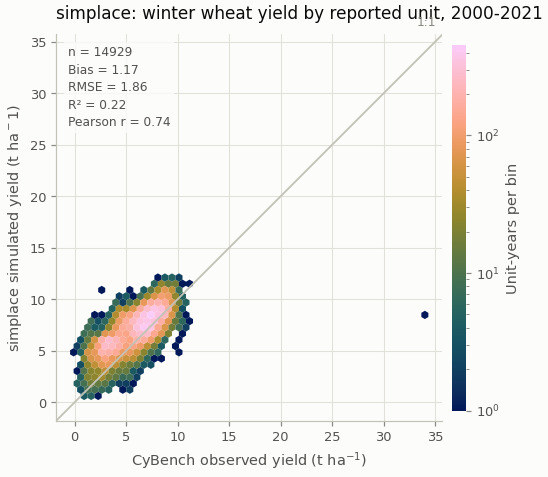

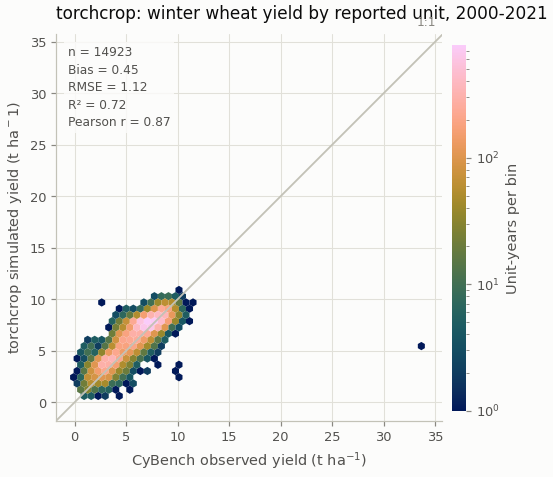

In [12]:
for model, block in yield_paired.groupby("model"):
    # A density, not a scatter: ~17 000 unit-years per model would plot as one
    # opaque blob and the 1:1 line would be the only thing readable on it.
    fig = cmeval.plots.scatter_density(
        block, "obs_yield", "yield_t_ha", stats=yield_pooled[model],
        cmap=colormaps.batlow,
        title=f"{model}: winter wheat yield by reported unit, "
              f"{block['year'].min()}-{block['year'].max()}",
        xlabel="CyBench observed yield (t ha$^{-1}$)",
        ylabel=f"{model} simulated yield (t ha$^{-1}$)",
        cbar_label="Unit-years per bin",
    )
    cmeval.plots.save(fig, f"full_run_01_yield_scatter_{model}")
    # display(fig)

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_02_yield_bias_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_02_yield_bias_torchcrop(.png/.pdf)


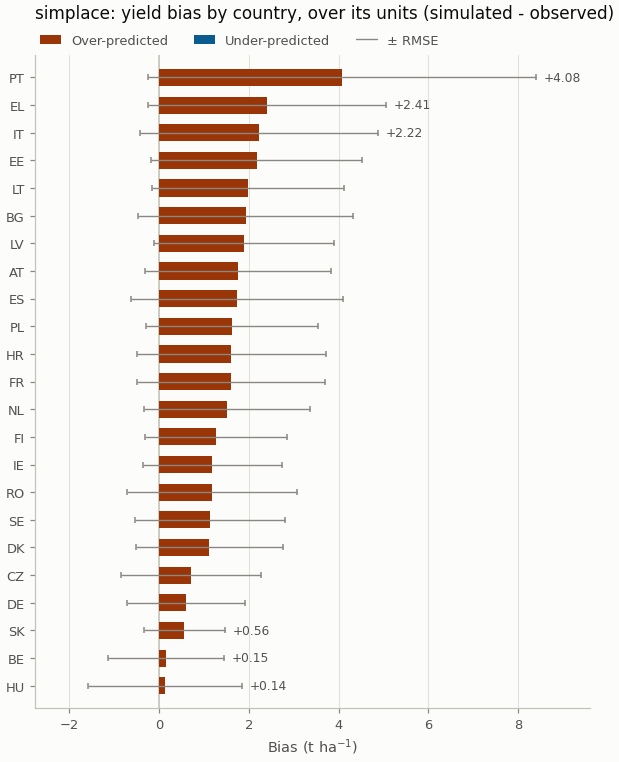

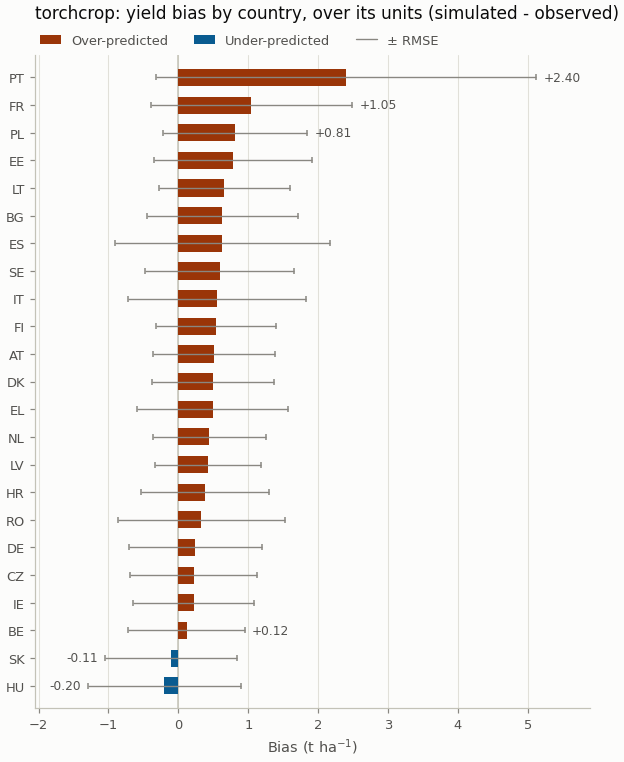

In [13]:
for model, table in yield_by_country.items():
    ranked = cmeval.metrics.rank_countries(table, by="rmse")
    fig = cmeval.plots.bias_bars(
        ranked, value_col="bias", error_col="rmse",
        title=f"{model}: yield bias by country, over its units "
              "(simulated - observed)",
        xlabel="Bias (t ha$^{-1}$)",
    )
    cmeval.plots.save(fig, f"full_run_02_yield_bias_{model}")
    # display(fig)

### 4.8 Figures — spatial maps, both models

Three resolutions of the same quantity, coarsest last: the 10 km cell mean is
what the model produced, the per-unit bias is what §4 actually scores, and the
per-country choropleth of §4.6 is that same bias rolled up. Reading them in
that order shows how much structure each aggregation step removes — the
national map cannot show a country that is too high in the north and too low in
the south, and the unit map can.

**The cell map is drawn over the full simulated domain, not `scoped`.** It
carries no observation, so the CyBench footprint is not a constraint on it —
restricting it there would blank out every simulated cell in a country CyBench
publishes no wheat for (CH, SI, LU, NO, CY, MT, IS) and every cell outside the
EU+Schengen scope entirely (UK, the Balkans west of the EU border, the eastern
edge of the grid), while saying nothing about what the model did there. The two
bias maps below *are* differences against CyBench and stay on the evaluable
units by necessity, so the cell map covering more ground than they do is the
intended contrast, not an inconsistency.

The shared colour scale therefore spans the full domain on both models, which
includes marginal cells the scored subset excludes; the 0–13.5 t/ha range is
set by real cells, not by an outlier.

`polygons` (the dissolved national footprints) is loaded here because §5 uses
it too.

INFO cropmodelling4eu.evaluation.regions: 946 admin polygons across 23 countries
INFO cropmodelling4eu.evaluation.regions: dissolved to 23 national footprints


torchcrop : 68,685 cells mapped (38,279 outside the CyBench footprint of §3)


INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_06_yield_map_torchcrop(.png/.pdf)


simplace  : 68,685 cells mapped (38,279 outside the CyBench footprint of §3)


INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_06_yield_map_simplace(.png/.pdf)


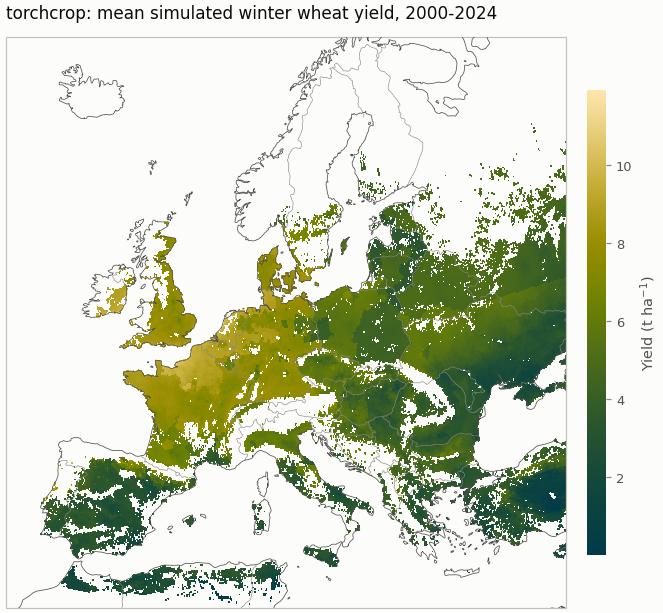

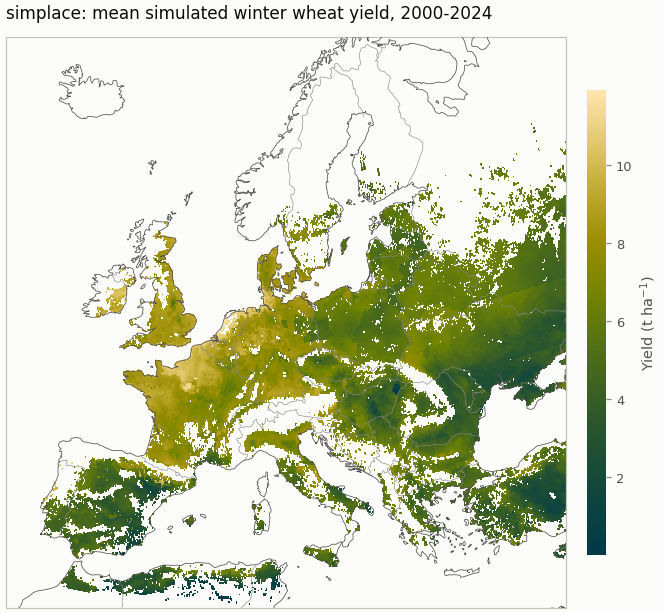

In [14]:
polygons = cmeval.regions.load_country_polygons(COUNTRIES)

# `runs`, not `scoped`: this map carries no observation, so the CyBench country
# footprint has nothing to say about it -- see the note above.
cell_means = {
    model: frame.groupby(["SimplaceID", "lon", "lat"], as_index=False)["yield_t_ha"].mean()
    for model, frame in runs.items()
}
# One shared scale across both models -- otherwise a pale SIMPLACE map next to
# a saturated TorchCrop one would hide a real difference behind mismatched bars.
yield_vmin = min(cm["yield_t_ha"].min() for cm in cell_means.values())
yield_vmax = max(cm["yield_t_ha"].max() for cm in cell_means.values())

for model, cell_mean in cell_means.items():
    frame = runs[model]
    dropped = len(cell_mean) - scoped[model]["SimplaceID"].nunique()
    print(f"{model:10s}: {len(cell_mean):>6,} cells mapped "
          f"({dropped:,} outside the CyBench footprint of §3)")
    fig = cmeval.plots.cell_map(
        cell_mean, "yield_t_ha",
        cmap=colormaps.bamako, vmin=yield_vmin, vmax=yield_vmax,
        title=f"{model}: mean simulated winter wheat yield, "
              f"{frame['year'].min()}-{frame['year'].max()}",
        cbar_label="Yield (t ha$^{-1}$)",
    )
    cmeval.plots.save(fig, f"full_run_06_yield_map_{model}")
    # display(fig)

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_07_yield_bias_map_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_07_yield_bias_map_torchcrop(.png/.pdf)


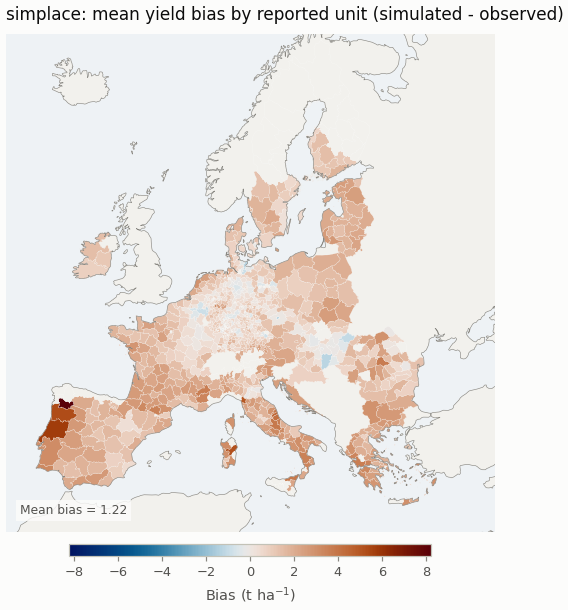

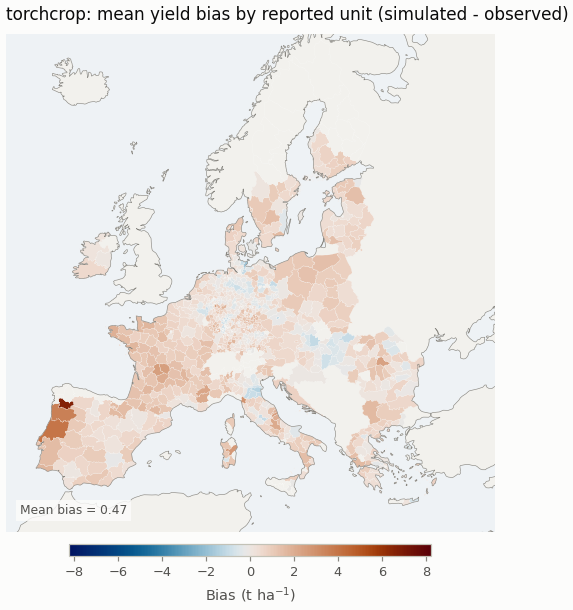

In [15]:
# Shared vmax across both models and both resolutions, so the same colour means
# the same bias whichever of the four maps it is read off.
unit_bias_vmax = max(
    table["bias"].drop("ALL", errors="ignore").abs().max()
    for table in yield_by_region.values()
)

for model, table in yield_by_region.items():
    fig = cmeval.plots.country_choropleth(
        admin, table["bias"], key_col="adm_id",
        cmap=colormaps.vik, vmax=unit_bias_vmax,
        # 0.6 pt of outline on ~800 units covers the fill it is meant to
        # separate; at this density the boundaries have to recede.
        linewidth=0.12,
        title=f"{model}: mean yield bias by reported unit (simulated - observed)",
        cbar_label="Bias (t ha$^{-1}$)", diverging=True, mean_label="Mean bias",
    )
    cmeval.plots.save(fig, f"full_run_07_yield_bias_map_{model}")
    # display(fig)

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_14_yield_bias_map_country_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_14_yield_bias_map_country_torchcrop(.png/.pdf)


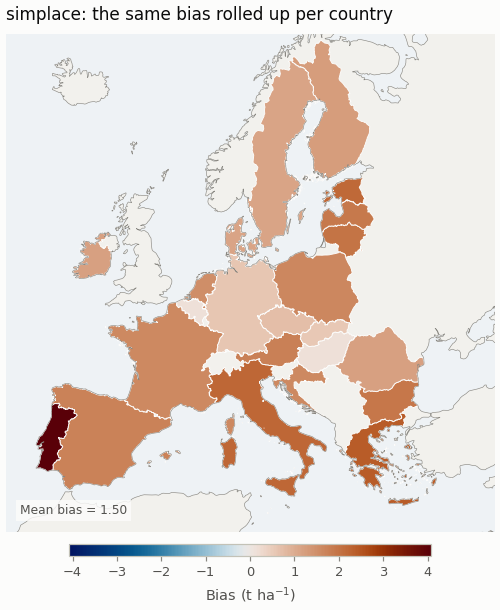

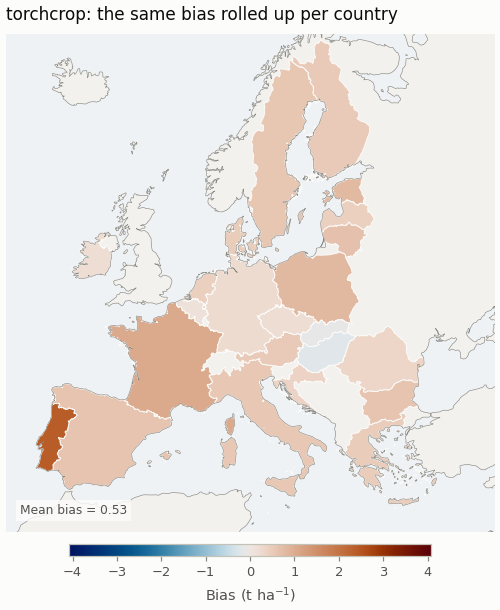

In [16]:
country_bias_vmax = max(
    table["bias"].drop("ALL", errors="ignore").abs().max()
    for table in yield_by_country.values()
)

for model, table in yield_by_country.items():
    fig = cmeval.plots.country_choropleth(
        polygons, table["bias"],
        cmap=colormaps.vik, vmax=country_bias_vmax,
        title=f"{model}: the same bias rolled up per country",
        cbar_label="Bias (t ha$^{-1}$)", diverging=True, mean_label="Mean bias",
    )
    cmeval.plots.save(fig, f"full_run_14_yield_bias_map_country_{model}")
    # display(fig)

### 4.9 Overview panel — yield, inter-annual spread, and bias, side by side

Everything §4.3-4.8 established separately, on one figure and at the reported
unit. Top row is mean yield — CyBench, then each model — on one shared colour
scale across all three, so a paler map next to a saturated one is a real
difference rather than an artefact of auto-scaling. Bottom row keeps CyBench's
own inter-annual std on its own scale (it is a different quantity from a bias
against it) while the two bias panels share theirs. Each panel carries the
pooled mean of what it shows, so the map and the number cannot disagree.

The observed panels are drawn over the **paired** rows, not over all of
CyBench: a unit with no simulated cell is not part of this comparison and
would otherwise colour the map with evidence no model was scored on.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_11_yield_overview_panel(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_11_yield_overview_panel.png')

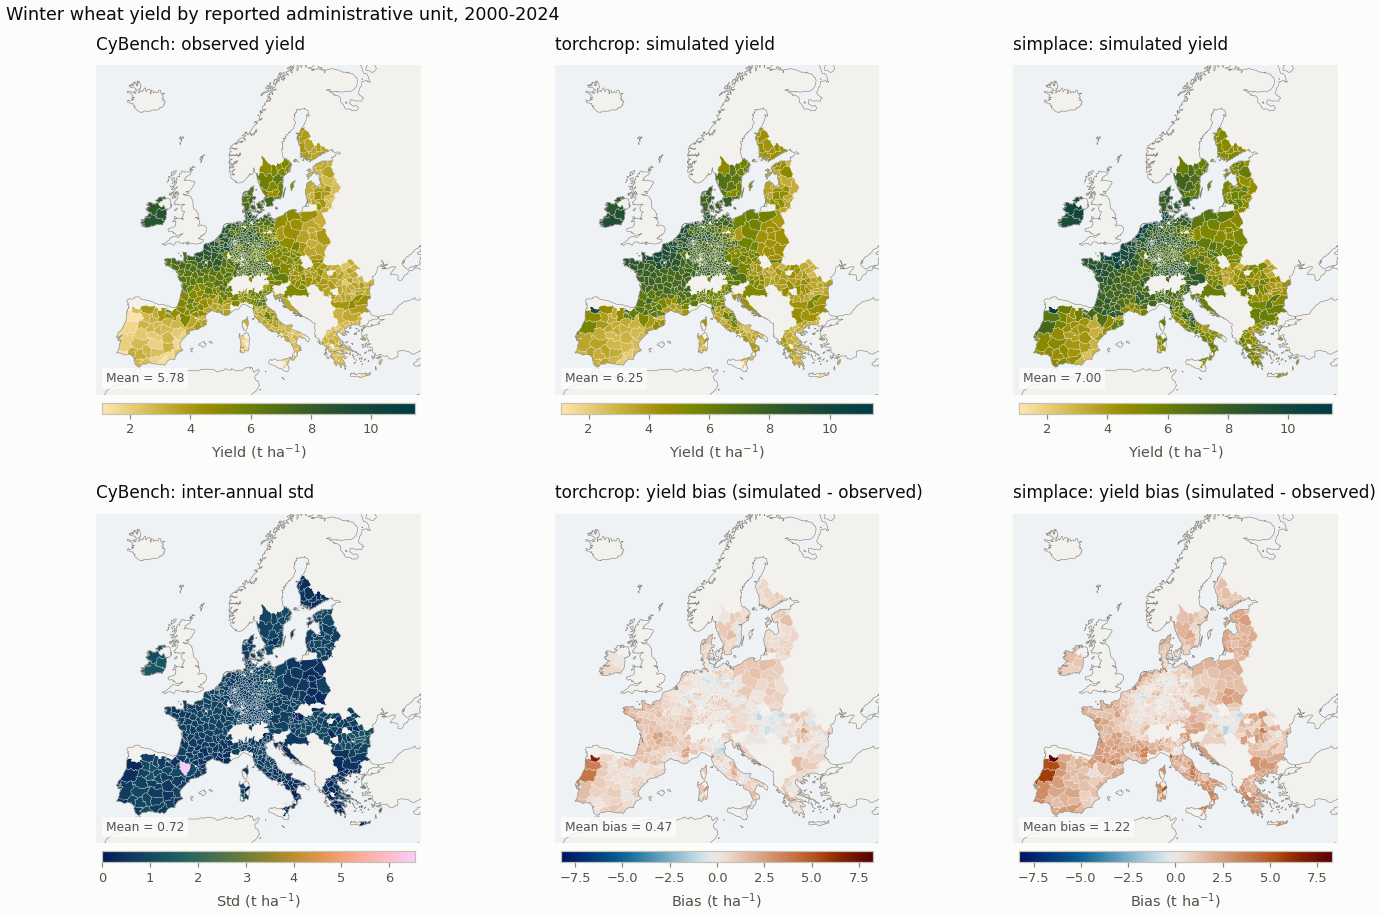

In [17]:
model_order = [m for m in ("torchcrop", "simplace") if m in yield_paired["model"].unique()]
n_cols = 1 + len(model_order)

# The observed side, over exactly the pairs that were scored -- one model's
# rows suffice, since every model is paired against the same reference.
paired_obs = yield_paired[yield_paired["model"] == model_order[0]]
obs_mean = paired_obs.groupby("adm_id")["obs_yield"].mean()
obs_std = paired_obs.groupby("adm_id")["obs_yield"].std()

model_mean = {
    m: yield_paired.loc[yield_paired["model"] == m].groupby("adm_id")["yield_t_ha"].mean()
    for m in model_order
}
model_bias = {m: yield_by_region[m]["bias"].drop("ALL", errors="ignore")
              for m in model_order}

row1 = [obs_mean, *model_mean.values()]
panel_vmin = min(v.min() for v in row1)
panel_vmax = max(v.max() for v in row1)
bias_vmax = max(v.abs().max() for v in model_bias.values())

fig, axes = plt.subplots(
    2, n_cols, figsize=(4.4 * n_cols, 8.6),
    subplot_kw={"projection": cmeval.plots.EUROPE_PROJECTION},
)

cmeval.plots.country_choropleth(
    admin, obs_mean, key_col="adm_id", ax=axes[0, 0], diverging=False,
    vmin=panel_vmin, vmax=panel_vmax, cmap=colormaps.bamako_r, linewidth=0.12,
    title="CyBench: observed yield", cbar_label="Yield (t ha$^{-1}$)",
    mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    cmeval.plots.country_choropleth(
        admin, model_mean[m], key_col="adm_id", ax=axes[0, i], diverging=False,
        vmin=panel_vmin, vmax=panel_vmax, cmap=colormaps.bamako_r, linewidth=0.12,
        title=f"{m}: simulated yield", cbar_label="Yield (t ha$^{-1}$)",
        mean_label="Mean",
    )

cmeval.plots.country_choropleth(
    admin, obs_std, key_col="adm_id", ax=axes[1, 0], diverging=False,
    cmap=colormaps.batlow, linewidth=0.12,
    title="CyBench: inter-annual std", cbar_label="Std (t ha$^{-1}$)",
    mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    cmeval.plots.country_choropleth(
        admin, model_bias[m], key_col="adm_id", ax=axes[1, i], diverging=True,
        vmax=bias_vmax, cmap=colormaps.vik, linewidth=0.12,
        title=f"{m}: yield bias (simulated - observed)",
        cbar_label="Bias (t ha$^{-1}$)", mean_label="Mean bias",
    )

fig.suptitle(
    f"Winter wheat yield by reported administrative unit, "
    f"{min(common_years)}-{max(common_years)}",
    x=0.01, ha="left", color=PALETTE["primary"], fontsize=plt.rcParams["font.size"] + 2,
)
fig.tight_layout()
cmeval.plots.save(fig, "full_run_11_yield_overview_panel")
# display(fig)

## 5. Phenology — both models against CLMS HRL Croplands, per unit **and per year**

The observed crop calendar here is
[`data4simplace`'s CLMS phenology](../../src/data4simplace/CLMS_DOWNLOAD.md)
— the 10 m `CPMCE` (emergence) and `CPMCH` (harvest) rasters reduced over the
same CyBench reporting units §4 scores the yield on — not CyBench's own
`crop_calendar`.

**The reason is the year dimension.** `crop_calendar_wheat_<c>.csv` publishes
one static `sos`/`eos` per unit, so every model's interannual scatter is
scored as error and a model that responds correctly to a hot season is
penalised for it. CLMS carries a date per unit *and* per season, so §5.4 can
measure the interannual response instead of only the continental gradient —
the one thing the previous version of this section structurally could not do.

Three things it costs, all stated before any number is read:

| | CyBench `crop_calendar` | CLMS HRL Croplands |
| --- | --- | --- |
| Seasons | every simulated year, against one static value | **2017–2024 only**, 8 of the run's 25 |
| Units | 938 | 835 after the quality gates of §5.1 |
| Level | `eos` ≈ DOY 210 | `CPMCH` ≈ DOY 181 — **a month earlier**, §5.2 |

That last row is the trap. The two products describe the same event and
disagree on its level by nearly a month, so a bias against CLMS is not
comparable with a bias against CyBench, and §5.2 measures the disagreement
*before* any model bias is shown.

**All three stages are now like-for-like.** Both runs write an emergence date
— SIMPLACE's `Phenology.EmergenceDOY`, torchcrop's `tsump = tsumem` crossing —
so the emergence row is a genuine bias rather than the sowing-date proxy
earlier versions of this notebook reported as a lag, and §5.8's season length
is scored emergence → maturity against CLMS's emergence → harvest instead of
carrying the sowing-to-emergence gap as an apparent error. Emergence is the
only row that scores `tsumem` directly, which is what
[`CALIBRATION.md`](../CALIBRATION.md) stage 1 needs from this run.

In [18]:
for stage in cmeval.config.CLMS_STAGES:
    print(f"{stage.label:14s} {stage.sim_col:20s} vs CLMS '{stage.obs_col}'")
    print(f"  {stage.caveat}\n")

Emergence      emergence_doy        vs CLMS 'obs_emergence_doy'
  Like-for-like, and new: SIMPLACE writes Phenology.EmergenceDOY and torchcrop writes days_to_emergence from the tsump = tsumem crossing, so both sides mean 'the day the crop came up'. This is the only row that scores tsumem directly. Earlier runs of this notebook paired the *sowing* date here and reported the residual as a lag; those numbers are not comparable with these.

Harvest        maturity_doy         vs CLMS 'obs_harvest_doy'
  The clean pairing, with one level caveat. SIMPLACE's maturity_doy is the date of its own HarvestManagement.DoHarvest row and torchcrop's harvest_doy equals maturity (no drydown), so both sides mean 'the day the crop came off'. CPMCH, however, sits about a month earlier than every other harvest reference on disk -- see the offset check in the notebook before reading the bias as model error.

Season length  emergence_to_maturity_days vs CLMS 'obs_season_length_days'
  Endpoint-matched: emerge

### 5.1 Load the reference and pair on (unit, season)

`clms.load_phenology` applies three quality gates and logs what each one
costs, so the survivor count is the honest denominator for everything below:

| Gate | Why |
| --- | --- |
| `split_validated` | `CTY` class 1110 is "wheat" with no winter/spring split; the reducer recovers it from the emergence year in `CPMCE`'s `YYDOY`. A zone-year where the two modes did not separate carries a label that is not an observation |
| `n_pixels >= CLMS_MIN_PIXELS` | 10 000 pixels at 10 m is 1 km² of winter wheat. Below that the median of the pixel distribution describes a handful of fields, not a unit |
| `season_share >= CLMS_MIN_SEASON_SHARE` | where winter wheat is a small minority of the unit's wheat, the autumn mode the split rests on is thin |

The point estimate is the **median** of the unit's pixel distribution, not its
mean: the distribution is bounded below by the product's compositing step and
skewed above by the late tail of a re-sown field.

The pairing key is `(country, adm_id, year)` — the same units as §4, with the
season now a *key on both sides* rather than a key on one and a broadcast
constant on the other.

In [19]:
CLMS_STAGE_COLS = {stage.sim_col: stage.circular for stage in cmeval.config.CLMS_STAGES}
# Carried alongside the scored stages, not scored itself: sowing is an *input*
# on both sides, so a bias against it would measure the site table rather than
# a model. It is here so 5.8 can report the run's own sowing -> emergence lag,
# the quantity tsumem sets.
CLMS_STAGE_COLS["sowing_doy"] = True

clms_obs = cmeval.clms.load_phenology(COUNTRIES, zone="adm", years=(min(common_years),
                                                             max(common_years)))
print(f"CLMS {cmeval.config.CLMS_CROP}: {len(clms_obs):,} (unit, season) rows across "
      f"{clms_obs['adm_id'].nunique():,} units, "
      f"{clms_obs['year'].min()}-{clms_obs['year'].max()}")

phen_paired = []
for model, frame in scoped_adm.items():
    frame = frame.copy()
    # Both loaders now derive `emergence_to_maturity_days` -- the endpoint-
    # matched duration CLMS observes -- alongside the run's own sowing-based
    # `season_length_days`. Nothing is reconstructed here; a run missing either
    # column simply drops that stage from `available` below.
    available = {c: circ for c, circ in CLMS_STAGE_COLS.items() if c in frame.columns}
    sim_region = cmeval.aggregate.aggregate_simulated(
        frame, available, by=["country", "adm_id", "year"]
    )
    paired = cmeval.aggregate.pair_observations(
        sim_region, clms_obs, ["country", "adm_id", "year"]
    )
    paired["model"] = model
    phen_paired.append(paired)
phen_paired = pd.concat(phen_paired, ignore_index=True, sort=False)
phen_paired["nuts_level"] = cmeval.regions.nuts_level(phen_paired["adm_id"])

print(f"\n{len(phen_paired):,} paired (model, unit, season) rows across "
      f"{phen_paired['adm_id'].nunique():,} of {clms_obs['adm_id'].nunique():,} "
      f"observed units, {phen_paired['country'].nunique()} countries and "
      f"{phen_paired['year'].nunique()} seasons")
print(phen_paired.groupby("nuts_level", dropna=False)["adm_id"].nunique()
      .rename("units").to_frame().T.to_string())
phen_paired.head()

INFO cropmodelling4eu.evaluation.clms: CLMS wheat_winter: 0 rows dropped (split not validated)
INFO cropmodelling4eu.evaluation.clms: CLMS wheat_winter: 754 rows dropped (< 10,000 pixels)
INFO cropmodelling4eu.evaluation.clms: CLMS wheat_winter: 441 rows dropped (season share < 0.2)
INFO cropmodelling4eu.evaluation.clms: CLMS wheat_winter: 0 rows dropped (outside the country set)
INFO cropmodelling4eu.evaluation.clms: CLMS wheat_winter: 0 rows dropped (outside 2000-2024)
INFO cropmodelling4eu.evaluation.clms: CLMS wheat_winter (adm): 5895 of 110959 rows kept — 835 zones x 8 years


CLMS wheat_winter: 5,895 (unit, season) rows across 835 units, 2017-2024


INFO cropmodelling4eu.evaluation.aggregate: simulated: 21217 country-groups, 1-388 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 5811 rows; 15406 simulated-only and 84 observed-only dropped
WARNING cropmodelling4eu.evaluation.aggregate: countries present on only one side: ['FI']
INFO cropmodelling4eu.evaluation.aggregate: simulated: 21225 country-groups, 1-388 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 5811 rows; 15414 simulated-only and 84 observed-only dropped
WARNING cropmodelling4eu.evaluation.aggregate: countries present on only one side: ['FI']



11,622 paired (model, unit, season) rows across 815 of 835 observed units, 22 countries and 8 seasons
nuts_level   2    3
units       62  753


,country,adm_id,year,emergence_doy,sim_method,n_cells,maturity_doy,emergence_to_maturity_days,sowing_doy,obs_emergence_doy,...,emergence_doy_p90,harvest_doy_p10,harvest_doy_p90,season_length_days_p10,season_length_days_p90,n_pixels,area_km2,season_share,model,nuts_level
0,AT,AT11,2017,254.364477,unweighted,45,195.955193,306.590504,245.198774,285.0,...,305.0,170.0,188.0,244.0,273.0,809153,80.9153,0.214270,torchcrop,2
1,AT,AT11,2018,257.658391,unweighted,45,192.222341,299.563677,245.755279,300.0,...,322.0,164.0,188.0,219.0,259.0,2012857,201.2857,0.496247,torchcrop,2
2,AT,AT11,2019,254.859932,unweighted,45,195.244847,305.384027,245.399414,297.0,...,310.0,176.0,188.0,233.0,263.0,2450920,245.0920,0.637079,torchcrop,2
3,AT,AT11,2020,255.262607,unweighted,45,199.222447,308.959598,244.088874,306.0,...,316.0,170.0,195.0,226.0,266.0,2200419,220.0419,0.600960,torchcrop,2
4,AT,AT11,2022,254.883102,unweighted,45,195.134100,305.250224,244.088874,308.0,...,317.0,164.0,188.0,216.0,257.0,1409010,140.9010,0.341606,torchcrop,2


### 5.2 The two references disagree by a month — measure that first

`CPMCH` sits well earlier than every other harvest reference on disk. The
probe in `CLMS_DOWNLOAD.md` measured −52 d against SAGE on one season over
Brandenburg and left the cause open: either the layer dates senescence rather
than the combine, or 2022's drought advanced that harvest.

This is the continental version of that check, over 835 units, and it is run
**before** any model bias so that a change of reference cannot be mistaken for
a change in the models. What it shows is a level shift, not a disagreement
about pattern: the two references correlate strongly across units while
sitting a near-constant month apart.

INFO cropmodelling4eu.evaluation.cybench: observed calendars: 938 regions, 23 countries
INFO cropmodelling4eu.evaluation.cybench: crop masks: 946 regions
INFO cropmodelling4eu.evaluation.clms: 835 units on both references; CLMS obs_harvest_doy is -28.9 d from CyBench eos (median -29, r 0.87)


835 units carry both references
  CLMS CPMCH   mean DOY 181.1
  CyBench eos  mean DOY 210.0
  difference   mean -28.9 d, median -28.8, IQR -33.5 .. -24.5
  correlation across units r = 0.87 -- they agree on *where*, not on *when*


INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_16_clms_cybench_offset_map(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_16_clms_cybench_offset_map.png')

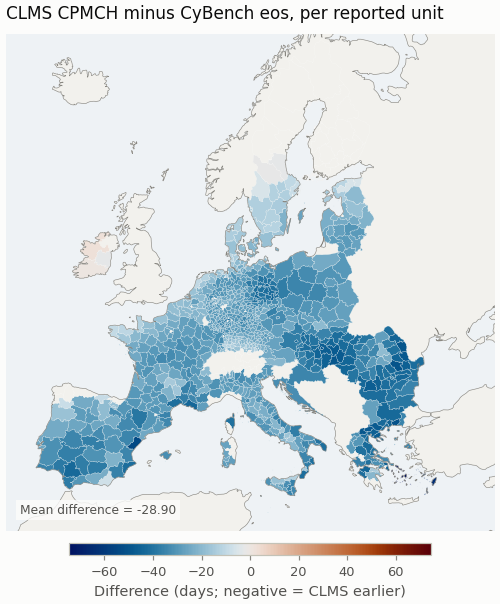

In [20]:
calendar = cmeval.cybench.load_calendar(COUNTRIES)
crop_mask = cmeval.cybench.load_crop_mask(COUNTRIES)

reference_offset = cmeval.clms.calendar_offset(clms_obs, calendar)
print(f"{len(reference_offset):,} units carry both references")
print(f"  CLMS CPMCH   mean DOY {reference_offset['obs_harvest_doy'].mean():.1f}")
print(f"  CyBench eos  mean DOY {reference_offset['eos'].mean():.1f}")
print(f"  difference   mean {reference_offset['difference'].mean():+.1f} d, "
      f"median {reference_offset['difference'].median():+.1f}, "
      f"IQR {reference_offset['difference'].quantile(.25):+.1f} .. "
      f"{reference_offset['difference'].quantile(.75):+.1f}")
print(f"  correlation across units r = "
      f"{reference_offset['obs_harvest_doy'].corr(reference_offset['eos']):.2f} "
      "-- they agree on *where*, not on *when*")
reference_offset.to_csv(cmeval.config.TABLE_DIR / "full_run_clms_cybench_offset.csv",
                        float_format="%.2f")

fig = cmeval.plots.country_choropleth(
    admin, reference_offset["difference"], key_col="adm_id",
    cmap=colormaps.vik, diverging=True, linewidth=0.12,
    title="CLMS CPMCH minus CyBench eos, per reported unit",
    cbar_label="Difference (days; negative = CLMS earlier)",
    mean_label="Mean difference",
)
cmeval.plots.save(fig, "full_run_16_clms_cybench_offset_map")
# display(fig)

### 5.3 Pooled skill by stage, both models

The same three cuts §4.5 uses — **all units**, **by NUTS level**, and
**sparse against resolved** — because a unit whose simulated date rests on one
or two 10 km cells is being asked a question the grid cannot answer.

Read the emergence row as what §5's caveat says it is: neither run emits an
emergence date, so its simulated column is the *sowing* date and the residual
is the observed sowing-to-emergence lag. It is the only place in either
notebook where `tsumem` is confronted with an observation.

In [21]:
RESOLVED_CELLS = cmeval.config.MIN_CELLS_PER_GRIDCELL

phen_pooled_rows = []
for stage in cmeval.config.CLMS_STAGES:
    if stage.sim_col not in phen_paired.columns:
        continue
    metric_fn = cmeval.metrics.phenology_metrics if stage.circular else cmeval.metrics.yield_metrics
    for model, block in phen_paired.groupby("model"):
        cuts = {
            "all units": block,
            **{f"NUTS-{int(lvl)}": part
               for lvl, part in block.groupby("nuts_level", dropna=True)},
            f"sparse (< {RESOLVED_CELLS} cells)": block[block["n_cells"] < RESOLVED_CELLS],
            f"resolved (>= {RESOLVED_CELLS} cells)": block[block["n_cells"] >= RESOLVED_CELLS],
        }
        for label, part in cuts.items():
            if part.empty:
                continue
            row = metric_fn(part[stage.obs_col], part[stage.sim_col])
            row.update(stage=stage.label, model=model, subset=label,
                       units=part["adm_id"].nunique())
            phen_pooled_rows.append(row)

phen_pooled_table = (
    pd.DataFrame(phen_pooled_rows).set_index(["stage", "subset", "model"])
    [["units", "n", "obs_mean", "sim_mean", "bias", "mae", "rmse", "pearson_r"]]
)
phen_pooled_table.to_csv(
    cmeval.config.TABLE_DIR / "full_run_phenology_metrics_by_subset.csv", float_format="%.3f"
)
phen_pooled_table.round(1)

units     n  obs_mean  sim_mean  bias   mae  rmse  pearson_r
stage         subset                model                                                                  
Emergence     all units             simplace     815  5811     306.4     286.3 -20.8  23.5  30.7        0.3
              NUTS-2                simplace      62   443     304.0     275.9 -28.3  29.6  33.8        0.5
              NUTS-3                simplace     753  5368     306.6     287.1 -20.2  23.0  30.5        0.3
              sparse (< 3 cells)    simplace      66   376     302.8     291.1 -12.2  18.7  25.6        0.2
              resolved (>= 3 cells) simplace     749  5435     306.6     285.9 -21.4  23.9  31.0        0.3
              all units             torchcrop    815  5811     306.4     285.9 -21.2  23.9  31.0        0.3
              NUTS-2                torchcrop     62   443     304.0     275.5 -28.7  30.1  34.2        0.5
              NUTS-3                torchcrop    753  5368     306.6     286.7 -20.6  23.4  30.7        0.3
              sparse (< 3 cells)    torchcrop     66   376     302.8     290.7 -12.7  19.1  25.9        0.2
              resolved (>= 3 cells) torchcrop    749  5435     306.6     285.5 -21.8  24.3  31.3        0.3
Harvest       all units             simplace     815  5811     181.3     194.0  12.6  13.0  14.6        0.9
              NUTS-2                simplace      62   443     186.4     196.1   9.8  10.1  11.5        0.9
              NUTS-3                simplace     753  5368     180.9     193.8  12.9  13.2  14.9        0.9
              sparse (< 3 cells)    simplace      66   376     185.6     196.5  10.9  11.4  13.2        0.9
              resolved (>= 3 cells) simplace     749  5435     181.0     193.8  12.8  13.1  14.7        0.9
              all units             torchcrop    815  5811     181.3     198.2  17.0  17.0  18.3        0.9
              NUTS-2                torchcrop     62   443     186.4     201.4  15.2  15.2  16.3        0.9
              NUTS-3                torchcrop    753  5368     180.9     197.9  17.2  17.2  18.4        0.9
              sparse (< 3 cells)    torchcrop     66   376     185.6     199.4  14.0  14.0  15.8        0.8
              resolved (>= 3 cells) torchcrop    749  5435     181.0     198.1  17.2  17.2  18.5        0.9
Season length all units             simplace     815  5811     239.3     272.6  33.3  33.5  38.9        0.8
              NUTS-2                simplace      62   443     246.3     284.8  38.5  38.7  41.9        0.8
              NUTS-3                simplace     753  5368     238.7     271.6  32.8  33.1  38.6        0.8
              sparse (< 3 cells)    simplace      66   376     247.0     270.0  23.0  24.8  31.2        0.7
              resolved (>= 3 cells) simplace     749  5435     238.8     272.7  34.0  34.2  39.4        0.8
              all units             torchcrop    815  5811     239.3     277.3  38.0  38.2  44.0        0.8
              NUTS-2                torchcrop     62   443     246.3     290.6  44.4  44.5  48.0        0.8
              NUTS-3                torchcrop    753  5368     238.7     276.2  37.5  37.7  43.7        0.8
              sparse (< 3 cells)    torchcrop     66   376     247.0     273.5  26.5  28.0  34.6        0.7
              resolved (>= 3 cells) torchcrop    749  5435     238.8     277.6  38.8  38.9  44.6        0.8

### 5.4 Where-skill against when-skill — what the year dimension buys

A pooled correlation over (unit, season) pairs mixes two different claims:
that the model puts the *continental gradient* in the right place, and that it
responds to the weather of a *particular season*. Against CyBench's static
calendar only the first exists, and the second is scored as noise.

`clms.split_skill` separates them:

* **`spatial_r`** — correlation of the per-unit means. Cornwall against
  Andalusia; this is what the previous version of §5 measured.
* **`anomaly_r`** — correlation of each unit's deviations from its own mean.
  Is 2018 early *here* because the model knows 2018 was hot here?
* **`obs_anomaly_sd` / `sim_anomaly_sd`** — the amplitude. A model can track
  the sign of every anomaly and still swing twice as far as the observation,
  which `anomaly_r` alone will not show.

In [22]:
skill_rows = []
for stage in cmeval.config.CLMS_STAGES:
    if stage.sim_col not in phen_paired.columns:
        continue
    for model, block in phen_paired.groupby("model"):
        row = cmeval.clms.split_skill(block, stage.obs_col, stage.sim_col,
                               circular=stage.circular)
        row.update(stage=stage.label, model=model)
        skill_rows.append(row)

skill_table = (
    pd.DataFrame(skill_rows).set_index(["stage", "model"])
    [["units", "n", "spatial_r", "anomaly_r", "obs_anomaly_sd", "sim_anomaly_sd"]]
)
skill_table.to_csv(cmeval.config.TABLE_DIR / "full_run_phenology_skill_split.csv",
                   float_format="%.3f")
skill_table.round(2)

units       n  spatial_r  anomaly_r  obs_anomaly_sd  sim_anomaly_sd
stage         model                                                                         
Emergence     simplace   815.0  5811.0       0.43       0.01           13.64            2.91
              torchcrop  815.0  5811.0       0.43      -0.00           13.64            3.08
Harvest       simplace   815.0  5811.0       0.95       0.66            6.14            4.71
              torchcrop  815.0  5811.0       0.95       0.68            6.14            4.63
Season length simplace   815.0  5811.0       0.87       0.34           14.20            4.56
              torchcrop  815.0  5811.0       0.82       0.34           14.20            5.04

### 5.5 Harvest skill per unit and per country, both models

Harvest is the pairing where both sides mean the same thing — SIMPLACE's
`maturity_doy` is the date of its own `HarvestManagement.DoHarvest` row and
torchcrop models no drydown, so both are "the day the crop came off" — subject
to the level offset §5.2 measured.

Both tables come from the **same unit-season pairs**; the per-country one is
their roll-up, exactly as §4.6 rolls up the yield pairs. The per-unit table is
written to disk rather than displayed (~800 rows per model); §5.6's map is the
readable form of it.

Unlike the previous version, `rmse` here is a scatter against a reference that
*also* varies by year, so it is a real error and not partly the model's own
interannual spread being counted against a constant.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_03_harvest_bias_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_03_harvest_bias_torchcrop(.png/.pdf)


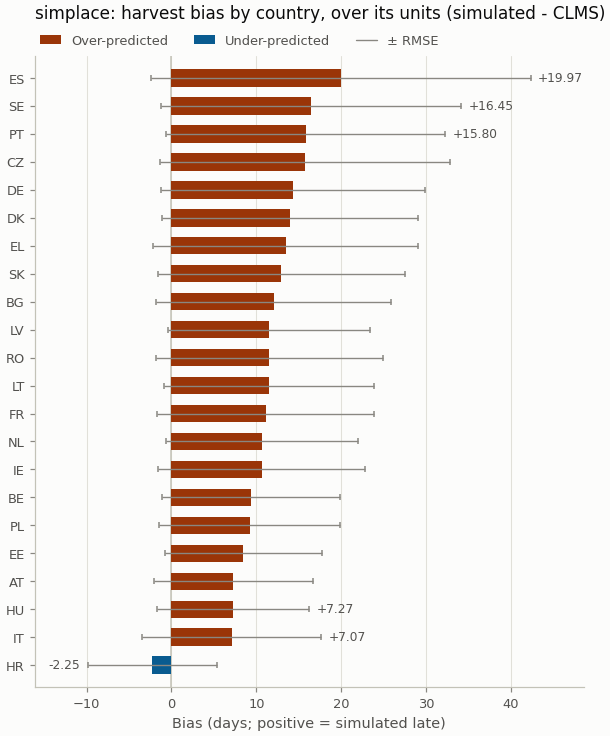

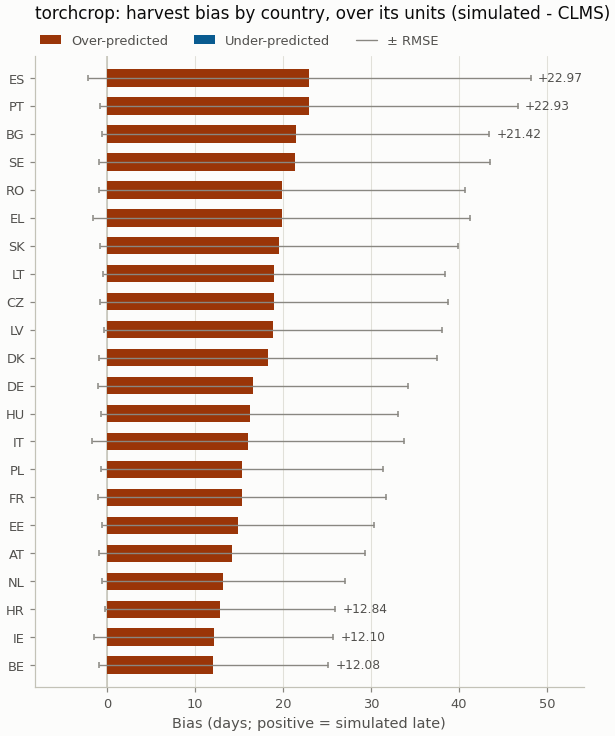

In [23]:
harvest_by_region = {
    model: cmeval.metrics.metrics_by_group(
        block, "obs_harvest_doy", "maturity_doy", group_col="adm_id",
        metric_fn=cmeval.metrics.phenology_metrics,
    )
    for model, block in phen_paired.groupby("model")
}
harvest_by_country = {
    model: cmeval.metrics.metrics_by_group(
        block, "obs_harvest_doy", "maturity_doy", metric_fn=cmeval.metrics.phenology_metrics
    )
    for model, block in phen_paired.groupby("model")
}

pd.concat(
    {model: table[["n", "bias", "rmse"]] for model, table in harvest_by_region.items()},
    axis=1,
).to_csv(cmeval.config.TABLE_DIR / "full_run_harvest_metrics_by_region.csv",
         float_format="%.3f")
pd.concat(
    {model: table[["n", "bias", "rmse"]] for model, table in harvest_by_country.items()},
    axis=1,
).to_csv(cmeval.config.TABLE_DIR / "full_run_harvest_metrics_by_country.csv",
         float_format="%.3f")

for model, table in harvest_by_country.items():
    ranked = cmeval.metrics.rank_countries(table, by="rmse")
    fig = cmeval.plots.bias_bars(
        ranked, value_col="bias", error_col="rmse",
        title=f"{model}: harvest bias by country, over its units "
              "(simulated - CLMS)",
        xlabel="Bias (days; positive = simulated late)",
    )
    cmeval.plots.save(fig, f"full_run_03_harvest_bias_{model}")
    # display(fig)

### 5.6 Figures — spatial harvest bias, both models

Two resolutions of one quantity, finest first: the per-unit bias is what §5.5
scores, and the per-country choropleth beneath it is that same bias rolled up.
A country harvested too early in its north and too late in its south cancels
to a clean national number, and only the unit map separates the two.

**One scale spans both models and both resolutions**, so a colour means the
same thing on any of the four maps — the §4.8 rule. Read them against the
§5.2 offset map: where the model bias here has the same sign and magnitude as
the CLMS-minus-CyBench difference there, the two maps are showing the same
property of the reference rather than two independent findings.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_08_harvest_bias_map_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_08_harvest_bias_map_torchcrop(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_15_harvest_bias_map_country_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_15_harvest_bias_map_country_torchcrop(.png/.pdf)


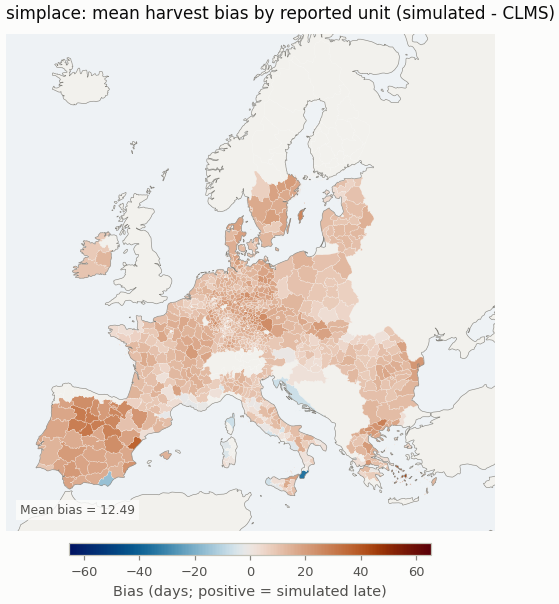

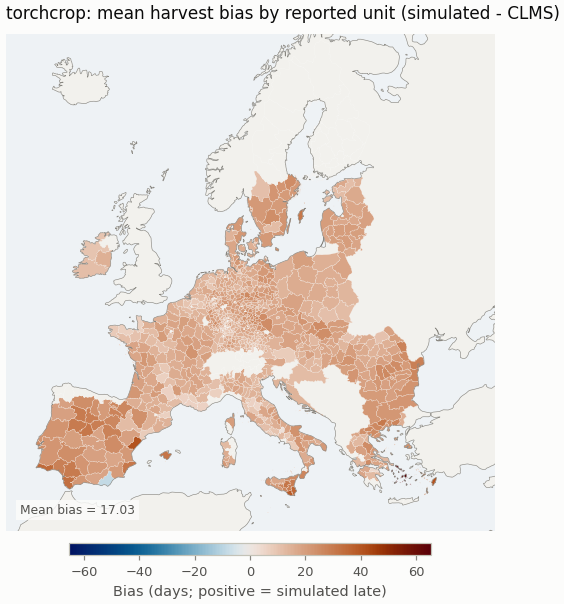

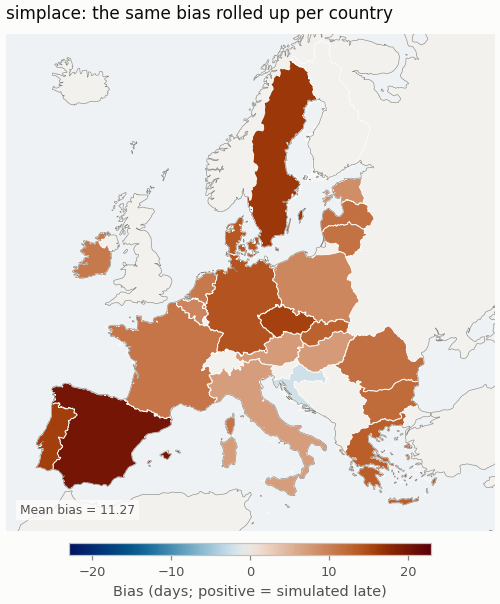

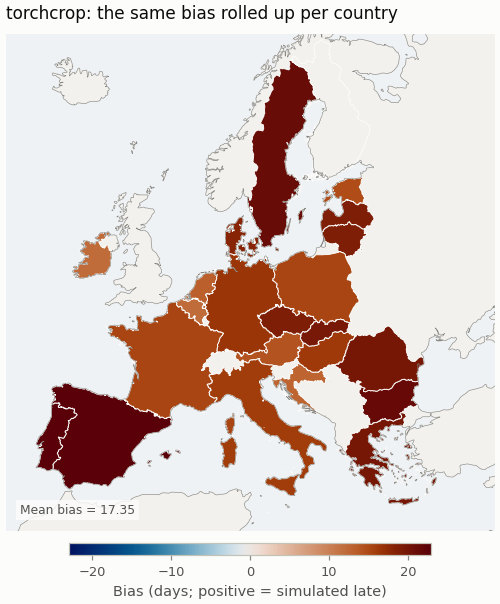

In [24]:
# One scale across both models and both resolutions, so the same colour means
# the same bias on whichever of the four maps it is read off.
harvest_bias_vmax = max(
    table["bias"].drop("ALL", errors="ignore").abs().max()
    for table in harvest_by_region.values()
)

for model, table in harvest_by_region.items():
    fig = cmeval.plots.country_choropleth(
        admin, table["bias"], key_col="adm_id",
        cmap=colormaps.vik, vmax=harvest_bias_vmax,
        # As in 4.8: 0.6 pt of outline on ~800 units covers the fill it is
        # meant to separate.
        linewidth=0.12,
        title=f"{model}: mean harvest bias by reported unit (simulated - CLMS)",
        cbar_label="Bias (days; positive = simulated late)", diverging=True,
        mean_label="Mean bias",
    )
    cmeval.plots.save(fig, f"full_run_08_harvest_bias_map_{model}")
    # display(fig)

country_harvest_vmax = max(
    table["bias"].drop("ALL", errors="ignore").abs().max()
    for table in harvest_by_country.values()
)

for model, table in harvest_by_country.items():
    fig = cmeval.plots.country_choropleth(
        polygons, table["bias"].drop("ALL", errors="ignore"),
        cmap=colormaps.vik, vmax=country_harvest_vmax,
        title=f"{model}: the same bias rolled up per country",
        cbar_label="Bias (days; positive = simulated late)", diverging=True,
        mean_label="Mean bias",
    )
    cmeval.plots.save(fig, f"full_run_15_harvest_bias_map_country_{model}")
    # display(fig)

### 5.7 Overview panel — harvest, with the observed inter-annual spread

Same layout and same units as §4.9, for the harvest date: observed per unit,
then each model's circular mean over that unit's cells, on one shared scale;
the two bias panels share a second.

**The bottom-left panel is new.** §5's previous version turned that axis off,
because a climatological reference has no year-to-year spread to show. CLMS
does, so the panel now carries the observed inter-annual standard deviation of
the harvest date — the quantity §5.4's `obs_anomaly_sd` summarises to one
number, and the yardstick the two bias panels beside it should be read
against. A bias smaller than the observation's own inter-annual swing is a
different kind of result from one several times larger.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_12_harvest_overview_panel(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_12_harvest_overview_panel.png')

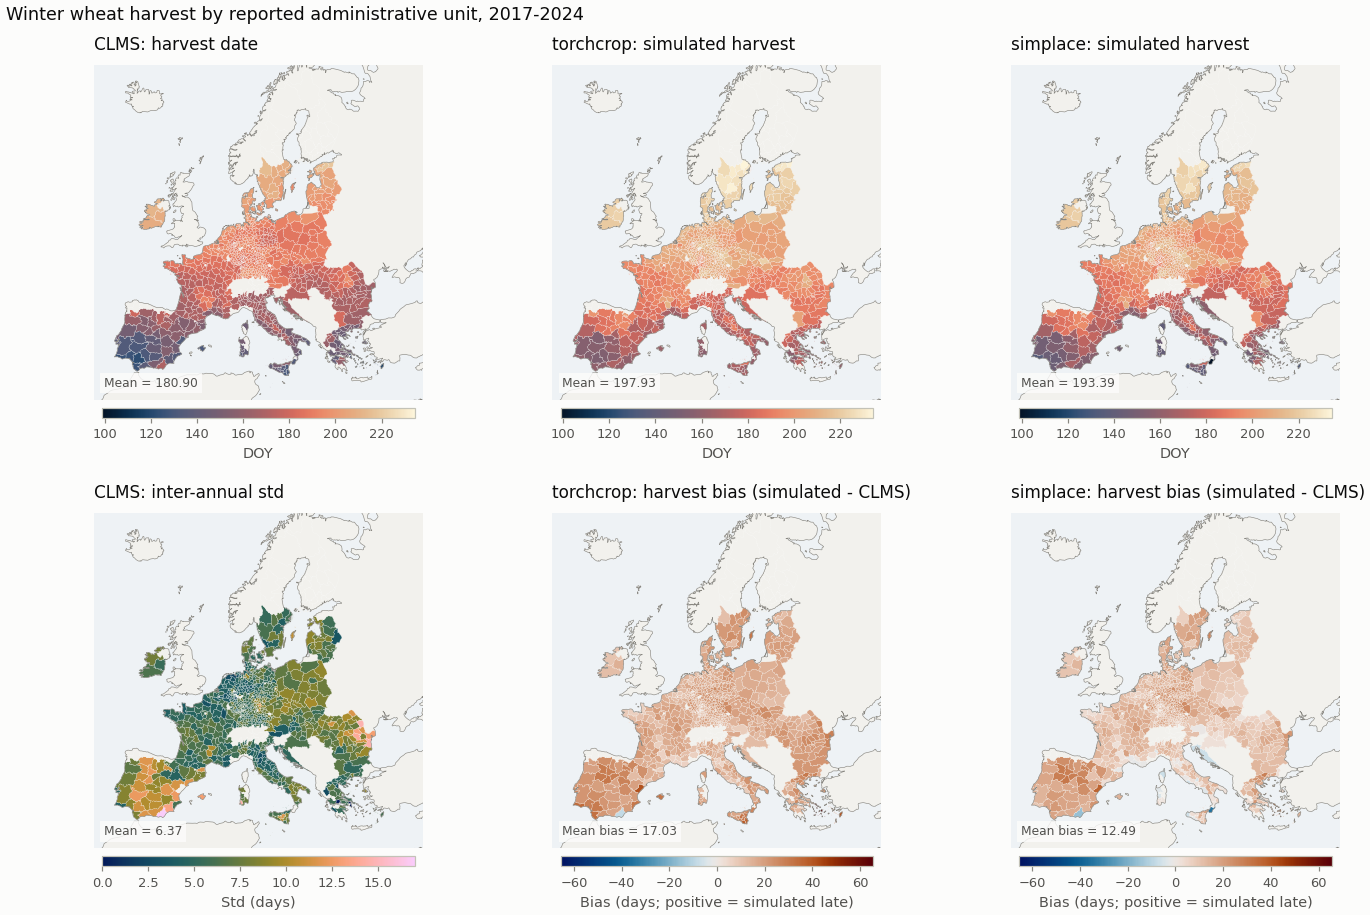

In [25]:
model_order = [m for m in ("torchcrop", "simplace") if m in phen_paired["model"].unique()]
n_cols = 1 + len(model_order)

# One model's rows suffice for the observed side: every model is paired
# against the same (unit, season) reference.
paired_obs = phen_paired[phen_paired["model"] == model_order[0]]
obs_harvest = paired_obs.groupby("adm_id")["obs_harvest_doy"].mean()
obs_harvest_std = paired_obs.groupby("adm_id")["obs_harvest_doy"].std()

model_harvest_mean = {m: harvest_by_region[m]["sim_mean"].drop("ALL", errors="ignore")
                      for m in model_order}
model_harvest_bias = {m: harvest_by_region[m]["bias"].drop("ALL", errors="ignore")
                      for m in model_order}

row1 = [obs_harvest, *model_harvest_mean.values()]
harvest_vmin = min(v.min() for v in row1)
harvest_vmax = max(v.max() for v in row1)

fig, axes = plt.subplots(
    2, n_cols, figsize=(4.4 * n_cols, 8.6),
    subplot_kw={"projection": cmeval.plots.EUROPE_PROJECTION},
)

cmeval.plots.country_choropleth(
    admin, obs_harvest, key_col="adm_id", ax=axes[0, 0], diverging=False,
    vmin=harvest_vmin, vmax=harvest_vmax, cmap=colormaps.lipari, linewidth=0.12,
    title="CLMS: harvest date", cbar_label="DOY", mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    cmeval.plots.country_choropleth(
        admin, model_harvest_mean[m], key_col="adm_id", ax=axes[0, i],
        diverging=False, vmin=harvest_vmin, vmax=harvest_vmax,
        cmap=colormaps.lipari, linewidth=0.12,
        title=f"{m}: simulated harvest", cbar_label="DOY", mean_label="Mean",
    )

cmeval.plots.country_choropleth(
    admin, obs_harvest_std, key_col="adm_id", ax=axes[1, 0], diverging=False,
    cmap=colormaps.batlow, linewidth=0.12,
    title="CLMS: inter-annual std", cbar_label="Std (days)", mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    cmeval.plots.country_choropleth(
        admin, model_harvest_bias[m], key_col="adm_id", ax=axes[1, i],
        diverging=True, vmax=harvest_bias_vmax, cmap=colormaps.vik, linewidth=0.12,
        title=f"{m}: harvest bias (simulated - CLMS)",
        cbar_label="Bias (days; positive = simulated late)", mean_label="Mean bias",
    )

fig.suptitle(
    f"Winter wheat harvest by reported administrative unit, "
    f"{phen_paired['year'].min()}-{phen_paired['year'].max()}",
    x=0.01, ha="left", color=PALETTE["primary"], fontsize=plt.rcParams["font.size"] + 2,
)
fig.tight_layout()
cmeval.plots.save(fig, "full_run_12_harvest_overview_panel")
# display(fig)

### 5.8 Season length — and whether the two endpoint offsets close

Both endpoints now match. The simulated season scored here is
**emergence → maturity** (`emergence_to_maturity_days`), against CLMS's
**emergence → harvest**; the run's own sowing-based `season_length_days` is
carried alongside but is not the pairing, because it would charge the whole
sowing-to-emergence lag to the season as an apparent error.

With matched endpoints the decomposition is an identity rather than an
approximation:

```
bias(season length) = bias(harvest) − bias(emergence)
```

The cell below computes both sides and prints the residual. A residual of a
day or two is the circular-versus-linear arithmetic and the medians used for
the endpoint biases; anything larger means the run's own season arithmetic
disagrees with the endpoint dates it wrote, and *that* is the finding.

The sowing-based duration is reported in the same table so the
sowing-to-emergence lag — the quantity `tsumem` controls — stays visible as
the difference between the two rows.

Durations stay linear here — `doy.doy_difference`'s shortest-path circular
error is the wrong tool for a 250-day season, which it would fold under
182.5 days.

In [26]:
SEASON_SIM = "emergence_to_maturity_days"

season_paired = phen_paired[
    phen_paired[SEASON_SIM].notna()
    & phen_paired["obs_season_length_days"].notna()
].copy()

# yield_metrics, not phenology_metrics -- a duration, so a plain bias.
season_by_region = {
    m: cmeval.metrics.metrics_by_group(block, "obs_season_length_days",
                                SEASON_SIM, group_col="adm_id")
    for m, block in season_paired.groupby("model")
}
season_by_country = {
    m: cmeval.metrics.metrics_by_group(block, "obs_season_length_days", SEASON_SIM)
    for m, block in season_paired.groupby("model")
}
pd.concat(
    {m: table[["n", "bias", "rmse"]] for m, table in season_by_country.items()}, axis=1
).to_csv(cmeval.config.TABLE_DIR / "full_run_season_length_metrics_by_country.csv",
         float_format="%.3f")

# Does the season-length bias decompose into the two endpoint biases?
closure_rows = []
for m, block in season_paired.groupby("model"):
    harvest_bias = cmeval.metrics.phenology_metrics(
        block["obs_harvest_doy"], block["maturity_doy"]
    )["bias"]
    emergence_bias = cmeval.metrics.phenology_metrics(
        block["obs_emergence_doy"], block["emergence_doy"]
    )["bias"]
    season_bias = cmeval.metrics.yield_metrics(
        block["obs_season_length_days"], block[SEASON_SIM]
    )["bias"]
    # Forward wrap: emergence follows sowing across the New Year for a winter
    # crop. This is the run's own sowing -> emergence lag, the quantity tsumem
    # sets, and it is the gap between the two season definitions.
    sim_lag = float(
        ((block["emergence_doy"] - block["sowing_doy"]) % cmeval.config.DAYS_IN_YEAR).median()
    )
    obs_lag = float(
        ((block["obs_emergence_doy"] - block["sowing_doy"]) % cmeval.config.DAYS_IN_YEAR).median()
    )
    closure_rows.append({
        "model": m,
        "harvest bias (d)": harvest_bias,
        "emergence bias (d)": emergence_bias,
        "expected season bias (d)": harvest_bias - emergence_bias,
        "actual season bias (d)": season_bias,
        "residual (d)": season_bias - (harvest_bias - emergence_bias),
        "sim sowing->emergence (d)": sim_lag,
        "obs sowing->emergence (d)": obs_lag,
    })
closure = pd.DataFrame(closure_rows).set_index("model")
closure.to_csv(cmeval.config.TABLE_DIR / "full_run_season_length_closure.csv",
               float_format="%.2f")
closure.round(1)

,harvest bias (d),emergence bias (d),expected season bias (d),actual season bias (d),residual (d),sim sowing->emergence (d),obs sowing->emergence (d)
model,,,,,,,
simplace,12.6,-20.8,33.4,33.3,-0.2,15.0,33.0
torchcrop,17.0,-21.2,38.2,38.0,-0.2,13.4,33.0


## 6. SIMPLACE against TorchCrop, directly

**No observation in this section — every number is a difference between the
two models**, signed `torchcrop − simplace` (`fullrun.pair_models`), the same
convention `stresstest_evaluation.ipynb` uses and for the same reason: calling
one side "simulated" and the other "observed" would claim a reference neither
run supports. This section needs both models and is skipped otherwise.

In [27]:
BOTH_MODELS = len(runs) == 2
if not BOTH_MODELS:
    print("Only one model has a finished run -- skipping the direct comparison. "
          "Re-run this notebook once the other has been collected.")
else:
    model_pairs = cmeval.fullrun.pair_models(runs)
    print(f"{len(model_pairs):,} (cell, year) pairs common to both runs "
          f"(of {len(runs['simplace']):,} simplace, {len(runs['torchcrop']):,} torchcrop)")
    model_pairs.head()

INFO cropmodelling4eu.evaluation.fullrun: 1711322 (cell, year) pairs common to both runs (of 1716665 simplace, 1711524 torchcrop)


1,711,322 (cell, year) pairs common to both runs (of 1,716,665 simplace, 1,711,524 torchcrop)


### 6.1 Do the two runs share a sowing date?

Zero everywhere is what `submit_cropmodelling.sh`'s chained run is *for* —
SIMPLACE's simulated date handed straight to torchcrop's shard array. The
comparison is against the *corrected* SIMPLACE date, not
`simplace_europe.parquet`'s own raw `sowing_doy` column: that column is one
day earlier than the day the crop actually starts growing (the solution's
`DefaultManagement`/`SowingRule` component order means `DoSow` reads
*yesterday's* rule result — see `collect.sowing_table`'s docstring), and
`sowing_from_simplace.csv` corrects it by +1 before torchcrop ever reads it.
`fullrun.pair_models` applies the same +1 before differencing, so a properly
chained run reads 0 here too. Anything else means torchcrop sowed from its
own convention instead (a per-cell site table date, or the DOY 270 constant
for a run made before the site stage), and every later stage in this section
is comparing two different seasons.

In [28]:
if BOTH_MODELS:
    mismatch = (model_pairs["sowing_doy_delta"] != 0).mean()
    print(f"{mismatch:.1%} of paired cell-years sow on a different day.")
    display(model_pairs["sowing_doy_delta"].describe().to_frame())

5.8% of paired cell-years sow on a different day.


,sowing_doy_delta
count,1.711322e+06
mean,4.027483e-01
std,2.339368e+00
min,-6.700000e+01
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,5.800000e+01


### 6.2 Agreement, pooled over every paired cell-season

In [29]:
if BOTH_MODELS:
    rows = []
    for key, label, is_date in [
        ("yield_t_ha", "Yield (t/ha)", False),
        ("biomass_g_m2", "Biomass (g/m2)", False),
        ("max_lai", "Peak LAI (m2/m2)", False),
        ("maturity_doy", "Maturity (DOY)", True),
    ]:
        simplace_col, torchcrop_col = f"{key}_simplace", f"{key}_torchcrop"
        if simplace_col not in model_pairs:
            continue
        fn = cmeval.metrics.phenology_metrics if is_date else cmeval.metrics.yield_metrics
        rows.append(fn(model_pairs[simplace_col], model_pairs[torchcrop_col]) | {"variable": label})
    agreement = pd.DataFrame(rows).set_index("variable")
    agreement.to_csv(cmeval.config.TABLE_DIR / "full_run_model_agreement.csv", float_format="%.3f")
    agreement.round(3)

### 6.3 Figure — yield agreement

The 1:1 line is the only reference drawn: there is no observation to regress
on here, so a fitted line would suggest a skill this run cannot measure.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_04_model_agreement_yield(.png/.pdf)


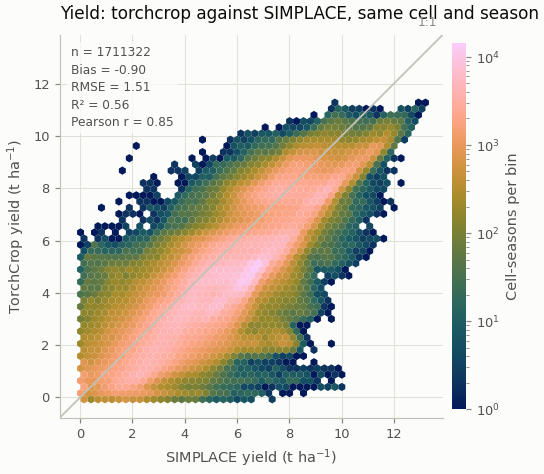

In [30]:
if BOTH_MODELS:
    stats = cmeval.metrics.yield_metrics(
        model_pairs["yield_t_ha_simplace"], model_pairs["yield_t_ha_torchcrop"]
    )
    fig = cmeval.plots.scatter_density(
        model_pairs, "yield_t_ha_simplace", "yield_t_ha_torchcrop", stats=stats,
        cmap=colormaps.batlow,
        title="Yield: torchcrop against SIMPLACE, same cell and season",
        xlabel="SIMPLACE yield (t ha$^{-1}$)",
        ylabel="TorchCrop yield (t ha$^{-1}$)",
        cbar_label="Cell-seasons per bin",
    )
    cmeval.plots.save(fig, "full_run_04_model_agreement_yield")
    # display(fig)

### 6.4 Figure — maturity agreement

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_05_model_agreement_maturity(.png/.pdf)


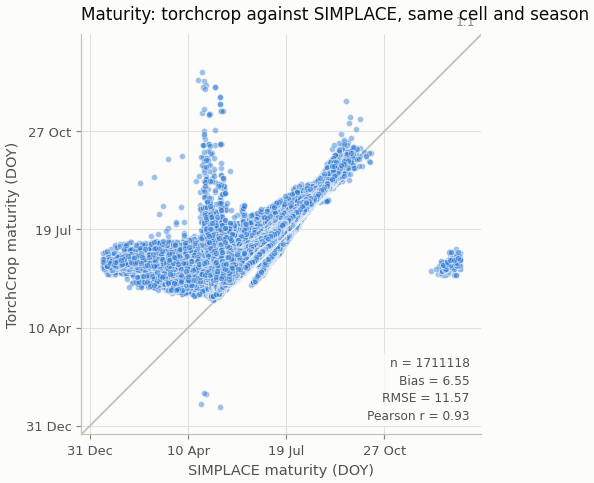

In [31]:
if BOTH_MODELS and "maturity_doy_simplace" in model_pairs:
    stats = cmeval.metrics.phenology_metrics(
        model_pairs["maturity_doy_simplace"], model_pairs["maturity_doy_torchcrop"]
    )
    fig = cmeval.plots.scatter_one_to_one(
        model_pairs, "maturity_doy_simplace", "maturity_doy_torchcrop",
        stats=stats, circular=True,
        title="Maturity: torchcrop against SIMPLACE, same cell and season",
        xlabel="SIMPLACE maturity (DOY)",
        ylabel="TorchCrop maturity (DOY)",
    )
    cmeval.plots.save(fig, "full_run_05_model_agreement_maturity")
    # display(fig)

### 6.5 Figure — spatial map of model disagreement

Signed `torchcrop - simplace` per cell, mean over the paired years — the
spatial counterpart of §6.2's pooled numbers, and the only way to see whether
the disagreement is a uniform offset or concentrated in particular regions.
The §6.1 sowing mismatch, in particular, need not affect every cell the same
way.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_09_model_agreement_yield_map(.png/.pdf)


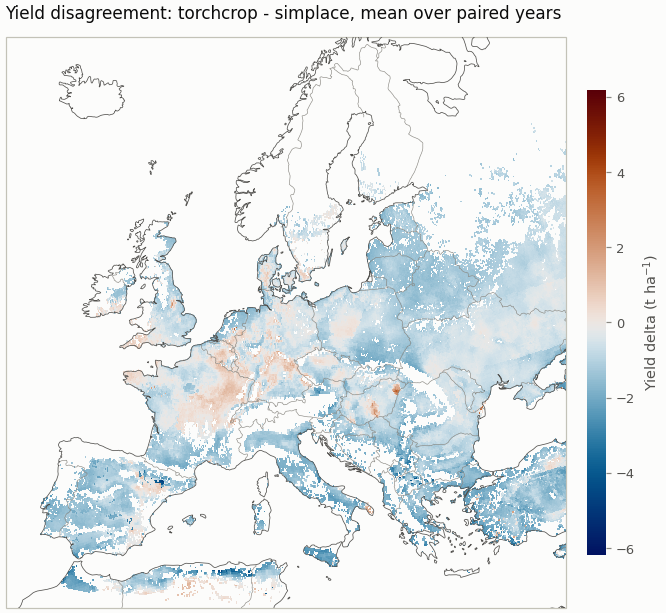

In [32]:
if BOTH_MODELS:
    cell_delta = model_pairs.groupby(
        ["SimplaceID", "lon", "lat"], as_index=False
    )[["yield_t_ha_delta", "maturity_doy_delta"]].mean()

    fig = cmeval.plots.cell_map(
        cell_delta, "yield_t_ha_delta",
        cmap=cmeval.plots.DIVERGING_CMAP, norm=cmeval.plots.diverging_norm(cell_delta["yield_t_ha_delta"]),
        title="Yield disagreement: torchcrop - simplace, mean over paired years",
        cbar_label="Yield delta (t ha$^{-1}$)",
    )
    cmeval.plots.save(fig, "full_run_09_model_agreement_yield_map")
    # display(fig)

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_10_model_agreement_maturity_map(.png/.pdf)


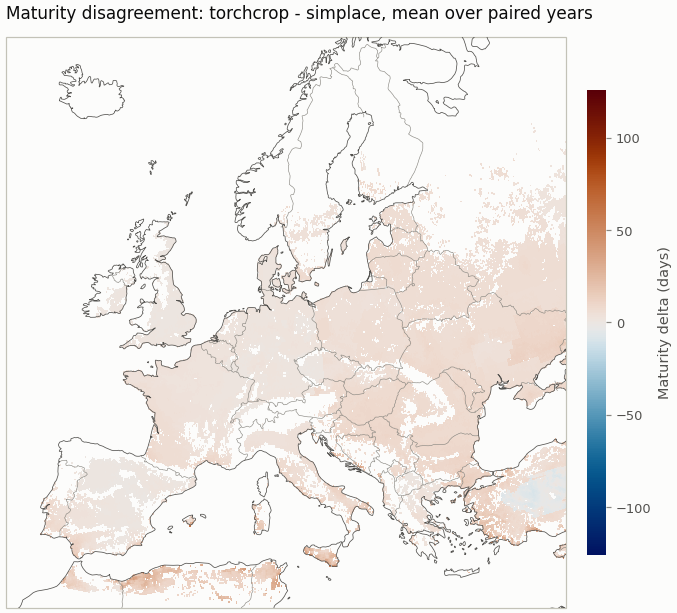

In [33]:
if BOTH_MODELS and "maturity_doy_delta" in model_pairs:
    fig = cmeval.plots.cell_map(
        cell_delta, "maturity_doy_delta",
        cmap=cmeval.plots.DIVERGING_CMAP, norm=cmeval.plots.diverging_norm(cell_delta["maturity_doy_delta"]),
        title="Maturity disagreement: torchcrop - simplace, mean over paired years",
        cbar_label="Maturity delta (days)",
    )
    cmeval.plots.save(fig, "full_run_10_model_agreement_maturity_map")
    # display(fig)


### 6.6 Partitioning and stress — what neither model is scored on

Nothing in this section has an observation behind it. It is here because
[`CALIBRATION.md`](../CALIBRATION.md) stages 2 and 3 are specified against
these quantities, and a plan quoting a superseded run's numbers is worse than
one quoting none.

* **Harvest index** (`yield_g_m2 / biomass_g_m2`) is the one partitioning
  quantity with an independent anchor — 0.45–0.55 for winter wheat — so it
  separates "too little assimilate" from "assimilate sent to the wrong organ",
  which the yield bias alone cannot.
* **Peak LAI** is scored as a *rate of failure* below 1.5 m² m⁻² as well as a
  median: the canopy failure the plan targets is bimodal on specific cells,
  and a median hides it.
* **`tranrf` and `nni`** say whether water or nitrogen is limiting at all. A
  pooled `nni` near 1 means the N group of stage 2 has nothing to bite on —
  blocker 5 — and no amount of calibration makes an inactive stress
  identifiable.


In [34]:

diag_rows = []
for model, frame in runs.items():
    row = {"model": model, "n": len(frame)}
    if {"yield_g_m2", "biomass_g_m2"} <= set(frame.columns):
        hi = frame["yield_g_m2"] / frame["biomass_g_m2"].replace(0, np.nan)
        hi = hi.where(hi.between(0, 1))
        row |= {
            "biomass median (g/m2)": frame["biomass_g_m2"].median(),
            "HI median": hi.median(),
            "HI > 0.6 (%)": 100.0 * float((hi > 0.6).mean()),
        }
    if "max_lai" in frame.columns:
        row |= {
            "peak LAI median": frame["max_lai"].median(),
            "LAI 4-6 (%)": 100.0 * float(frame["max_lai"].between(4, 6).mean()),
            "LAI < 1.5 (%)": 100.0 * float((frame["max_lai"] < 1.5).mean()),
        }
    for stress in ("tranrf_mean", "nni_mean"):
        if stress in frame.columns:
            row[stress] = frame[stress].mean()
    if "final_dvs" in frame.columns:
        row["never matured (%)"] = 100.0 * float((frame["final_dvs"] < 2).mean())
    elif "days_to_maturity" in frame.columns:
        row["no maturity date (%)"] = 100.0 * float(frame["days_to_maturity"].isna().mean())
    diag_rows.append(row)

partitioning = pd.DataFrame(diag_rows).set_index("model")
partitioning.to_csv(cmeval.config.TABLE_DIR / "full_run_partitioning_diagnostics.csv",
                    float_format="%.4f")
partitioning.round(3)


,n,biomass median (g/m2),HI median,HI > 0.6 (%),peak LAI median,LAI 4-6 (%),LAI < 1.5 (%),tranrf_mean,nni_mean,never matured (%),no maturity date (%)
model,,,,,,,,,,,
torchcrop,1711524,1140.482,0.404,4.091,7.062,7.980,1.563,0.943,0.988,0.012,NaN
simplace,1716665,1667.907,0.333,0.000,6.176,32.015,2.613,NaN,NaN,NaN,0.219


## 7. Summary

In [35]:
yield_paired.to_csv(cmeval.config.TABLE_DIR / "full_run_yield_paired.csv",
                    index=False, float_format="%.4f")
phen_paired.to_csv(cmeval.config.TABLE_DIR / "full_run_phenology_paired.csv",
                   index=False, float_format="%.4f")
season_paired.to_csv(cmeval.config.TABLE_DIR / "full_run_season_length_paired.csv",
                     index=False, float_format="%.4f")
if BOTH_MODELS:
    model_pairs.to_csv(cmeval.config.TABLE_DIR / "full_run_model_pairs.csv",
                       index=False, float_format="%.4f")
print(f"tables written to {cmeval.config.TABLE_DIR}")
print(f"figures written to {cmeval.config.FIGURE_DIR}")

# Harvest against CLMS, not CyBench eos -- the two references sit ~29 d apart
# (S5.2), so this row is not comparable with an earlier run of this notebook.
harvest_pooled = {
    model: cmeval.metrics.phenology_metrics(block["obs_harvest_doy"], block["maturity_doy"])
    for model, block in phen_paired.groupby("model")
}
summary = pd.DataFrame({
    "yield RMSE (t/ha)": {m: round(v["rmse"], 2) for m, v in yield_pooled.items()},
    "yield Bias (t/ha)": {m: round(v["bias"], 2) for m, v in yield_pooled.items()},
    "yield Pearson r": {m: round(v["pearson_r"], 2) for m, v in yield_pooled.items()},
    "harvest RMSE (d)": {m: round(v["rmse"], 1) for m, v in harvest_pooled.items()},
    "harvest Bias (d)": {m: round(v["bias"], 1) for m, v in harvest_pooled.items()},
})
summary.index.name = f"over {yield_paired['adm_id'].nunique():,} reported units"
summary


tables written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/tables
figures written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures


,yield RMSE (t/ha),yield Bias (t/ha),yield Pearson r,harvest RMSE (d),harvest Bias (d)
over 805 reported units,,,,,
simplace,1.86,1.17,0.74,14.6,12.6
torchcrop,1.12,0.45,0.87,18.3,17.0


### What this notebook can and cannot say

* **§4-5 score each model against an external reference at the finest
  resolution that reference publishes** — the reported administrative unit,
  NUTS-3 for fifteen countries and NUTS-2 for eight. A unit either model gets
  wrong is a genuine finding; so is a gradient across a country, which the
  earlier national pairing could not see.
* **Finer than the reference is not available here.** CyBench ships one
  polygon set, and it is the one its statistics are reported on. The 10 km
  cell maps (§4.8, §6.5) are the model's own resolution and carry no
  observation. CLMS is 10 m underneath, but it is reduced onto these same
  units so that §4 and §5 score the same geography.
* **The unit pairs are not all equally well resolved.** A unit smaller than a
  10 km cell gets its simulated mean from one cell; §4.5 and §5.3 re-score the
  `>= 3 cell` subset separately, and a pooled number that improves sharply
  there is measuring the grid, not the model.
* **§5's harvest bias is not comparable with an earlier run of this
  notebook.** It is measured against CLMS `CPMCH`, which sits ~29 days earlier
  than the CyBench `eos` this section used to pair against (§5.2). The two
  references correlate at r 0.87 across units, so they agree on the spatial
  pattern and disagree on the level; the sign of the pooled bias flips purely
  because of that.
* **§5's emergence row is not a like-for-like pairing.** Neither run emits an
  emergence date, so its simulated column is the *sowing* date and the
  residual is the observed sowing-to-emergence lag. A real emergence
  comparison needs `EmergenceDOY` in the SIMPLACE solution's outputs and an
  emergence column in torchcrop's run schema; `simplace/collect.py` already
  maps the former if the solution starts writing it.
* **§6 cannot say which model is right.** It says whether the two production
  runs agree, and §6.1 says how much of any disagreement is simply a different
  sowing convention rather than a model difference — read it before the rest
  of the section.
* **This is the delivered pipeline, not a controlled experiment.** Unlike
  `stresstest_evaluation.ipynb`, nothing here has been forced equal except the
  year range (§2), so a disagreement in §6 can still come from the sowing
  date, the crop parameters, or the model physics — this notebook does not
  separate them. `stresstest_evaluation.ipynb` is where that separation is
  done.
* **Re-run once both arrays finish.** `submit/submit_cropmodelling.sh --status`
  reports what each stage has completed; §2's model list is this notebook's
  own record of what it actually saw.
